In [1]:
from __future__ import annotations

import argparse
import subprocess
import sys
from pathlib import Path

import numpy as np
from astropy.io import fits
from IPython.display import display

from lib import options, orbsub
from lib.ftp.downloadDaily import DataDownloader
from lib.fitsUtil.phaii import PHAII

Each entry in `BINS` is `[time_bin, energy_bin]`:

- `time_bin = [start, stop]` seconds relative to `T_ZERO`;
- `energy_bin = [emin, emax]` keV;
- use `None` for the full energy range.

In [ ]:
def data_dir_from_command_line(default: str = "test_files") -> Path:
    parser = argparse.ArgumentParser(add_help=False)
    parser.add_argument("--data-dir", type=Path, default=Path(default))
    parsed, _ = parser.parse_known_args()
    return parsed.data_dir

T_ZERO      = 687_014_224
DATA_DIR    = data_dir_from_command_line("test_files")
OUTPUT_DIR  = DATA_DIR / "osv_phaii"

# [[relative time range in s], [energy range in keV] or None]
E_BIN = [50, 300]

BINS = [
    [[280, 300], E_BIN],
    [[300, 320], E_BIN],
    [[400, 500], E_BIN],
    [[600, 700], E_BIN],
    [[800, 900], E_BIN],
    [[1000, 1100], None],
    [[1100, 1200], None],
]

DETECTORS               = ["b0", "b1"]
SPEC_TYPE               = "CSPEC"               # "CSPEC" (128 channels) or "CTIME" (8 channels)
ORBIT_OFFSETS           = ["30"]
COORDS                  = [288.0, 20.0]          # RA, Dec in degrees
DO_GEOMETRY             = True
RECALCULATE_ORBIT       = True
AUTO_DOWNLOAD           = True
OUTPUT_NAME             = ""                # blank -> OSV derives a name from T_ZERO

DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## Validation

Just to check if one wrote all the intervals properly

In [10]:
def validate_requests(bin_requests):
    expanded = []
    for index, item in enumerate(bin_requests):
        if len(item) != 2: raise ValueError(f"BINS[{index}] must be [time_bin, energy_bin_or_None]")

        time_bin, energy_bin = item
        if len(time_bin) != 2: raise ValueError(f"BINS[{index}] time bin must contain [start, stop]")

        start, stop = map(float, time_bin)
        if not start < stop: raise ValueError(f"BINS[{index}] must have start < stop")

        if energy_bin is not None:
            if len(energy_bin) != 2: raise ValueError(f"BINS[{index}] energy bin must contain [emin, emax]")
            emin, emax = map(float, energy_bin)
            if not emin < emax: raise ValueError(f"BINS[{index}] must have emin < emax")
            energy_bin = [emin, emax]

        expanded.append({"time": [start, stop], "energy": energy_bin})

    return expanded

REQUESTS        = validate_requests(BINS)
ANALYSIS_RANGE  = [
    min(request["time"][0] for request in REQUESTS),
    max(request["time"][1] for request in REQUESTS),
]

print(f"{len(BINS)} input bins -> {len(REQUESTS)} export bins")
print(f"OSV enclosing time range: {ANALYSIS_RANGE} s relative to T_ZERO")
REQUESTS[:5]

12 input bins -> 12 export bins
OSV enclosing time range: [280.0, 1700.0] s relative to T_ZERO


[{'time': [280.0, 300.0], 'energy': [50.0, 300.0]},
 {'time': [300.0, 320.0], 'energy': [50.0, 300.0]},
 {'time': [400.0, 500.0], 'energy': [50.0, 300.0]},
 {'time': [600.0, 700.0], 'energy': [50.0, 300.0]},
 {'time': [800.0, 900.0], 'energy': [50.0, 300.0]}]

## Run OSV and download missing inputs

OSV stores daily files in `DATA_DIR / YYMMDD`.

In [11]:
def make_osv_options(t_range):
    opts = options.OSV_Args()
    opts.data_dir = str(DATA_DIR.resolve())
    opts.save_dir = str(OUTPUT_DIR.resolve())
    opts.tzero = float(T_ZERO)
    opts.tRange = list(map(float, t_range))
    opts.offset = [str(value) for value in ORBIT_OFFSETS]
    opts.dets = list(DETECTORS)
    opts.spec_type = SPEC_TYPE.upper()
    opts.doGeom = bool(DO_GEOMETRY)
    opts.coords = list(map(float, COORDS)) if DO_GEOMETRY else ["", ""]
    opts.doGTI = bool(DO_GEOMETRY)
    opts.reCalcOrbit = bool(RECALCULATE_ORBIT)
    opts.name = OUTPUT_NAME
    return opts

def discover_files(t_range, period=None):
    opts = make_osv_options(t_range)
    analysis = orbsub.OrbSub(opts)
    if period is not None:
        analysis.period = float(period)
    analysis.find_files()  # also validates/aligns the OSV time range
    return analysis

def download_missing_files(analysis):
    missing = analysis.files.missingFiles
    spec_key = analysis.opts.spec_type.lower()

    for day in analysis.files.days:
        file_types = []
        if day in missing["pos"]:
            file_types.append("poshist")

        missing_detectors = sorted(set(missing[spec_key].get(day, [])))
        if missing_detectors:
            file_types.append(spec_key)

        if not file_types:
            continue

        day_dir = DATA_DIR / day
        day_dir.mkdir(parents=True, exist_ok=True)
        print(f"Downloading {day}: {file_types}; detectors={missing_detectors or 'not applicable'}")
        DataDownloader(day, day_dir).download_files(
            file_types=file_types,
            detectors=missing_detectors or None,
            max_workers=3,
        )

def run_osv(t_range):
    analysis = discover_files(t_range)

    if analysis.files.error:
        if not AUTO_DOWNLOAD:
            raise FileNotFoundError(analysis.files.errMes)
        print(analysis.files.errMes)
        download_missing_files(analysis)
        # Use fresh options because OSV's check() aligns tRange in place.
        analysis = discover_files(t_range)

    if analysis.files.error:
        raise FileNotFoundError(
            "Required inputs are still missing after download:\n" + analysis.files.errMes
        )

    if analysis.opts.reCalcOrbit:
        period_ok = analysis.calc_period()
        if not period_ok:
            print("Warning: orbit-period recalculation failed; OSV will use its default period.")
        # Rebuild from the original requested range. OSV check() aligns tRange in
        # place, so this prevents repeated alignment when calc_period() rechecks files.
        analysis = discover_files(t_range, period=analysis.period)
        if analysis.files.error:
            if not AUTO_DOWNLOAD:
                raise FileNotFoundError(analysis.files.errMes)
            download_missing_files(analysis)
            analysis = discover_files(t_range, period=analysis.period)
            if analysis.files.error:
                raise FileNotFoundError(analysis.files.errMes)

    if analysis.opts.doGeom:
        if not analysis.get_gti():
            print("Warning: GTI calculation failed; continuing with OSV quality flags.")
        if not analysis.get_steps():
            print("Warning: occultation-step calculation failed; continuing.")

    if not analysis.do_orbsub():
        raise RuntimeError("OSV orbital subtraction failed:\n" + analysis.orbErrMes)

    return analysis

OSV_RESULT = run_osv(ANALYSIS_RANGE)
print(f"Finished OSV analysis: {OSV_RESULT.opts.name}")
print(f"Available detectors: {sorted(OSV_RESULT.data)}")

Finished OSV analysis: 221009554
Available detectors: ['b0', 'b1']


## PHAII subset exporter

OSV's `Pha_data.write_phaii()` always writes every time row and energy channel, and its low-level writer hard-codes vector widths of 8 or 128. The code below reuses OSV's `PHAII` header/EBOUNDS/GTI implementation, but makes the SPECTRUM vector width dynamic so a selected energy range remains a valid PHAII file.

In [12]:
def _dynamic_spectrum_hdu(product, counts, exposure, quality, t_start, t_stop,
                          stat_error=None, background=False):

    # Build OSV's SPECTRUM extension with a dynamic channel-vector width.
    counts = np.asarray(counts)
    n_rows, n_channels = counts.shape

    # Ask OSV to create its standard SPECTRUM header using a supported width.
    original_pha, original_nchan = product.pha, product.nchan
    product.pha = np.zeros((n_rows, 8), dtype=np.int32)
    product.nchan = 8
    product.doEvents()
    header = product.eventsExt.header.copy()
    product.pha, product.nchan = original_pha, original_nchan

    header["DETCHANS"] = n_channels
    header["HDUCLAS2"] = "BKG" if background else "TOTAL"
    header["POISSERR"] = stat_error is None

    columns = [
        fits.Column(
            name="COUNTS", format=f"{n_channels}D",
            array=np.asarray(counts, dtype=float), unit="count",
            bscale=1, bzero=32768,
        )
    ]
    if stat_error is not None:
        columns.append(fits.Column(
            name="STAT_ERR", format=f"{n_channels}D",
            array=np.asarray(stat_error, dtype=float), unit="count",
        ))
    columns.extend([
        fits.Column(name="EXPOSURE", format="1E", array=np.asarray(exposure), unit="s"),
        fits.Column(name="QUALITY", format="1I", array=np.asarray(quality, dtype=np.int16)),
        fits.Column(name="TIME", format="1D", array=np.asarray(t_start), unit="s", bzero=product.trig),
        fits.Column(name="ENDTIME", format="1D", array=np.asarray(t_stop), unit="s", bzero=product.trig),
    ])
    return fits.BinTableHDU.from_columns(columns, header=header)

def write_osv_phaii(path, detector, t_start, t_stop, exposure, counts, edges,
                    quality, stat_error=None, background=False):
    path = Path(path)
    product = PHAII(
        (np.asarray(t_start), np.asarray(t_stop)),
        np.asarray(exposure),
        np.asarray(counts),
        detector,
        OSV_RESULT.opts.tzero,
        str(path),
        "Created from an OrbitalSubtractionGBM result with requested time/energy masks.",
        edges,
        OSV_RESULT.opts.coords[0] if OSV_RESULT.opts.doGeom else 0.0,
        OSV_RESULT.opts.coords[1] if OSV_RESULT.opts.doGeom else 0.0,
        0.0,
        np.asarray(counts).shape[1],
        qual=np.asarray(quality),
        statErr=stat_error,
    )
    product.doPrimary()
    product.primExt.header["DATATYPE"] = OSV_RESULT.opts.spec_type
    product.doEbounds()
    product.doGTI()
    spectrum = _dynamic_spectrum_hdu(
        product, counts, exposure, quality, t_start, t_stop,
        stat_error=stat_error, background=background,
    )
    fits.HDUList([product.primExt, product.eBoundsExt, spectrum, product.gtiExt]).writeto(
        path, overwrite=True
    )
    return path

def _number_tag(value): return f"{float(value):g}".replace("-", "m").replace(".", "p")

def export_request(detector, request):
    data = OSV_RESULT.data[detector]
    rel_start, rel_stop = request["time"]
    absolute_start = OSV_RESULT.opts.tzero + rel_start
    absolute_stop = OSV_RESULT.opts.tzero + rel_stop

    time_edges = np.asarray(data.data["src"][0])
    t_start, t_stop = time_edges[:, 0], time_edges[:, 1]
    # Select bins by centre, which is stable when requested edges are not exact native edges.
    time_centres = 0.5 * (t_start + t_stop)
    time_mask = (time_centres >= absolute_start) & (time_centres < absolute_stop)
    if not np.any(time_mask):
        raise ValueError(f"No native time bins overlap {request['time']} for {detector}")

    energy = request["energy"]
    e_min, e_max = np.asarray(data.eEdgeMin), np.asarray(data.eEdgeMax)
    if energy is None:
        energy_mask = np.ones(e_min.shape, dtype=bool)
        energy_tag = "fullE"
    else:
        requested_emin, requested_emax = energy
        # Keep native channels that overlap the requested energy interval.
        energy_mask = (e_max > requested_emin) & (e_min < requested_emax)
        energy_tag = f"E{_number_tag(requested_emin)}-{_number_tag(requested_emax)}keV"
    if not np.any(energy_mask):
        raise ValueError(f"No native energy channels overlap {energy} for {detector}")

    def subset(matrix): return np.asarray(matrix)[time_mask][:, energy_mask]

    source = subset(data.data["src"][1])
    source_error = subset(data.data["src"][3])
    background = subset(data.background["all"])
    background_error = subset(data.background["allerr"])
    source_exposure = np.asarray(data.data["src"][2])[time_mask]
    background_exposure = np.asarray(data.bkgExp["all"])[time_mask]
    quality = np.asarray(data.quality)[time_mask]
    edges = (e_min[energy_mask], e_max[energy_mask])

    stem = (
        f"glg_osv-{OSV_RESULT.opts.spec_type.lower()}_"
        f"T{_number_tag(rel_start)}-{_number_tag(rel_stop)}_"
        f"{energy_tag}_{OSV_RESULT.opts.name}_{detector}"
    )
    source_path = OUTPUT_DIR / f"{stem}.PHA"
    background_path = OUTPUT_DIR / f"{stem}.BAK"

    write_osv_phaii(
        source_path, detector,
        t_start[time_mask], t_stop[time_mask], source_exposure,
        source, edges, quality, stat_error=source_error, background=False,
    )
    write_osv_phaii(
        background_path, detector,
        t_start[time_mask], t_stop[time_mask], background_exposure,
        background, edges, quality, stat_error=background_error, background=True,
    )

    return {
        "detector": detector,
        "requested_time_s": request["time"],
        "requested_energy_keV": energy or "full native range",
        "time_rows": int(time_mask.sum()),
        "energy_channels": int(energy_mask.sum()),
        "source": source_path,
        "background": background_path,
    }

## Export every requested time/energy bin

In [13]:
EXPORTS = [
    export_request(detector, request)
    for detector in DETECTORS
    for request in REQUESTS
]

print(f"Wrote {2 * len(EXPORTS)} PHAII files to {OUTPUT_DIR.resolve()}")
display(EXPORTS[:5])

Wrote 48 PHAII files to C:\Users\ludov\Documents\py3\test_files\osv_phaii


[{'detector': 'b0',
  'requested_time_s': [280.0, 300.0],
  'requested_energy_keV': [50.0, 300.0],
  'time_rows': 5,
  'energy_channels': 4,
  'source': WindowsPath('test_files/osv_phaii/glg_osv-cspec_T280-300_E50-300keV_221009554_b0.PHA'),
  'background': WindowsPath('test_files/osv_phaii/glg_osv-cspec_T280-300_E50-300keV_221009554_b0.BAK')},
 {'detector': 'b0',
  'requested_time_s': [300.0, 320.0],
  'requested_energy_keV': [50.0, 300.0],
  'time_rows': 5,
  'energy_channels': 4,
  'source': WindowsPath('test_files/osv_phaii/glg_osv-cspec_T300-320_E50-300keV_221009554_b0.PHA'),
  'background': WindowsPath('test_files/osv_phaii/glg_osv-cspec_T300-320_E50-300keV_221009554_b0.BAK')},
 {'detector': 'b0',
  'requested_time_s': [400.0, 500.0],
  'requested_energy_keV': [50.0, 300.0],
  'time_rows': 24,
  'energy_channels': 4,
  'source': WindowsPath('test_files/osv_phaii/glg_osv-cspec_T400-500_E50-300keV_221009554_b0.PHA'),
  'background': WindowsPath('test_files/osv_phaii/glg_osv-cspec_T4

## Quick FITS validation

In [14]:
def validate_export(record):
    for key, expected_class in (("source", "TOTAL"), ("background", "BKG")):
        with fits.open(record[key], checksum=True) as hdul:
            assert [hdu.name for hdu in hdul] == ["PRIMARY", "EBOUNDS", "SPECTRUM", "GTI"]
            assert hdul[2].header["HDUCLAS4"] == "TYPEII"
            assert hdul[2].header["HDUCLAS2"] == expected_class
            assert hdul[2].header["DETCHANS"] == record["energy_channels"]
            assert len(hdul[1].data) == record["energy_channels"]
            assert len(hdul[2].data) == record["time_rows"]
            assert hdul[2].data["COUNTS"].shape[1] == record["energy_channels"]

for record in EXPORTS: validate_export(record)

print(f"Validated {2 * len(EXPORTS)} files.")

Validated 48 files.


# This compares the exports to the imports (you can skip it)

Source file: test_files\osv_phaii\glg_osv-cspec_T280-300_E50-300keV_221009554_b0.PHA
Background file: test_files\osv_phaii\glg_osv-cspec_T280-300_E50-300keV_221009554_b0.BAK
Compared shape: (5, 4)
Maximum source |PHAII − OSV|: 1.8189894035458565e-12
Maximum background |BAK − OSV|: 1.7621459846850485e-12


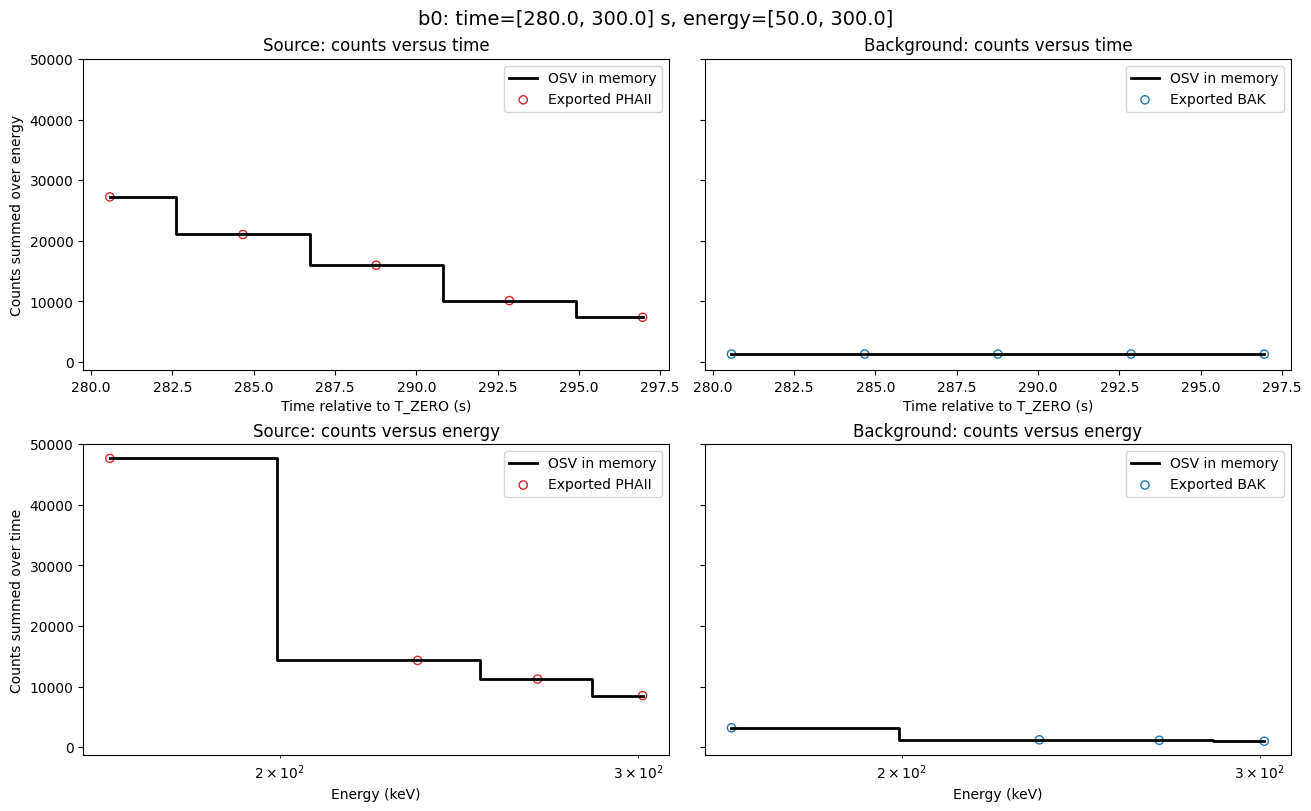

Source file: test_files\osv_phaii\glg_osv-cspec_T280-300_E50-300keV_221009554_b0.PHA
Background file: test_files\osv_phaii\glg_osv-cspec_T280-300_E50-300keV_221009554_b0.BAK
Compared shape: (5, 4)
Maximum source |PHAII − OSV|: 1.8189894035458565e-12
Maximum background |BAK − OSV|: 1.7621459846850485e-12


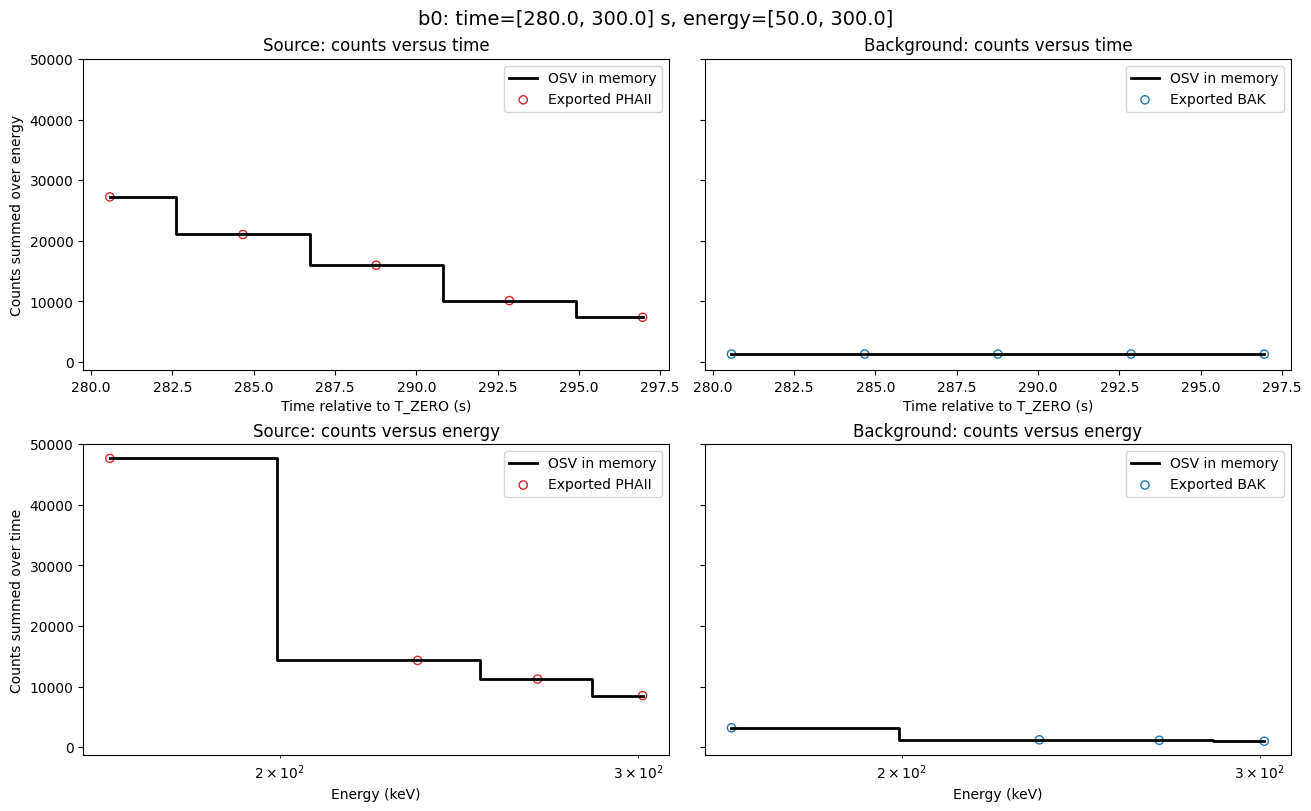

Source file: test_files\osv_phaii\glg_osv-cspec_T300-320_E50-300keV_221009554_b0.PHA
Background file: test_files\osv_phaii\glg_osv-cspec_T300-320_E50-300keV_221009554_b0.BAK
Compared shape: (5, 4)
Maximum source |PHAII − OSV|: 1.8189894035458565e-12
Maximum background |BAK − OSV|: 1.6484591469634324e-12


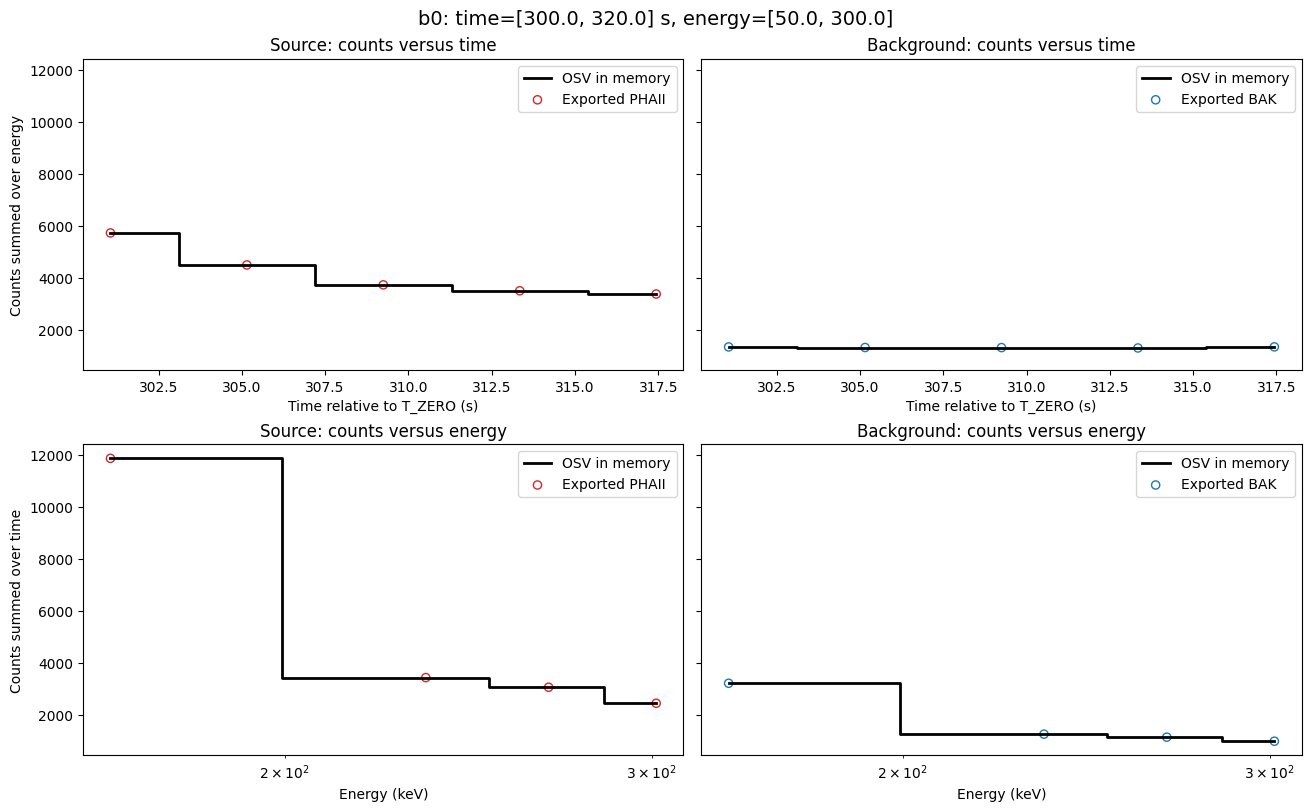

Source file: test_files\osv_phaii\glg_osv-cspec_T400-500_E50-300keV_221009554_b0.PHA
Background file: test_files\osv_phaii\glg_osv-cspec_T400-500_E50-300keV_221009554_b0.BAK
Compared shape: (24, 4)
Maximum source |PHAII − OSV|: 1.8189894035458565e-12
Maximum background |BAK − OSV|: 1.8189894035458565e-12


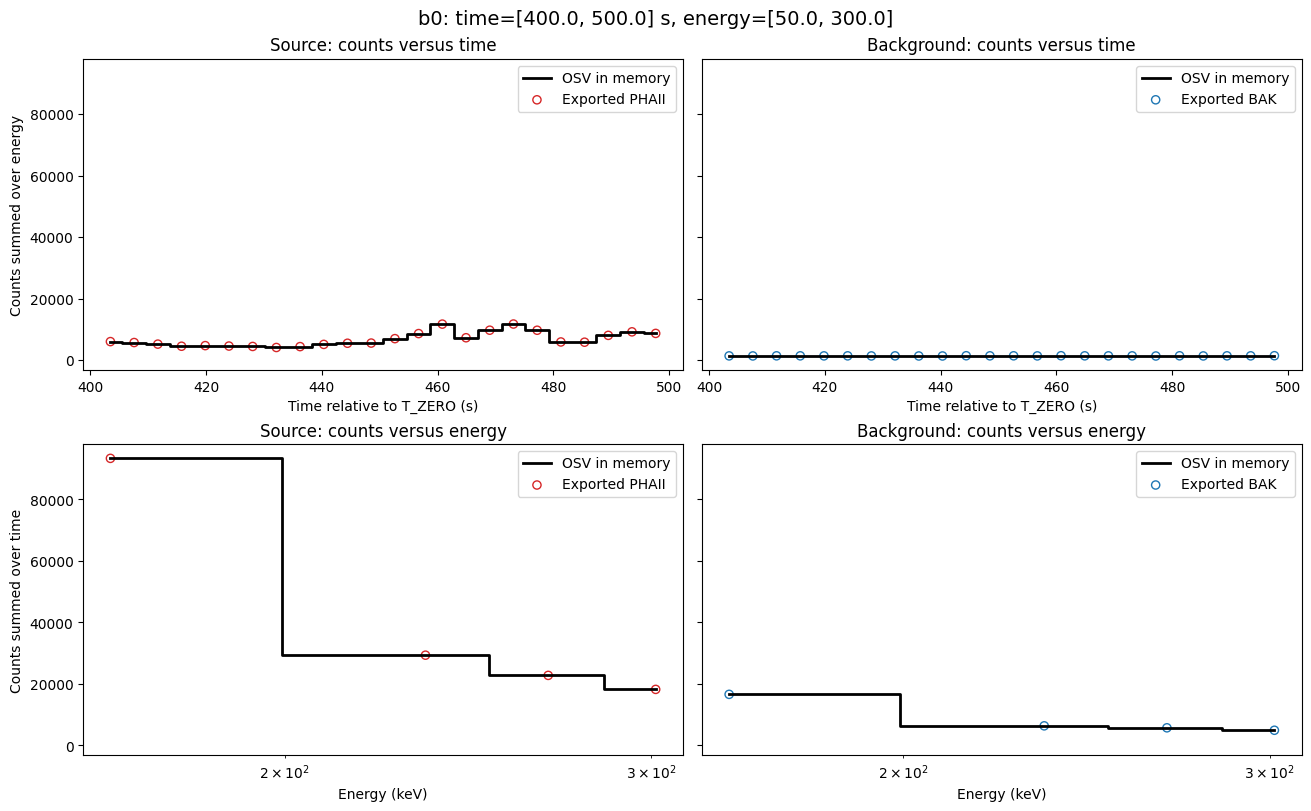

Source file: test_files\osv_phaii\glg_osv-cspec_T600-700_E50-300keV_221009554_b0.PHA
Background file: test_files\osv_phaii\glg_osv-cspec_T600-700_E50-300keV_221009554_b0.BAK
Compared shape: (25, 4)
Maximum source |PHAII − OSV|: 1.8189894035458565e-12
Maximum background |BAK − OSV|: 1.8189894035458565e-12


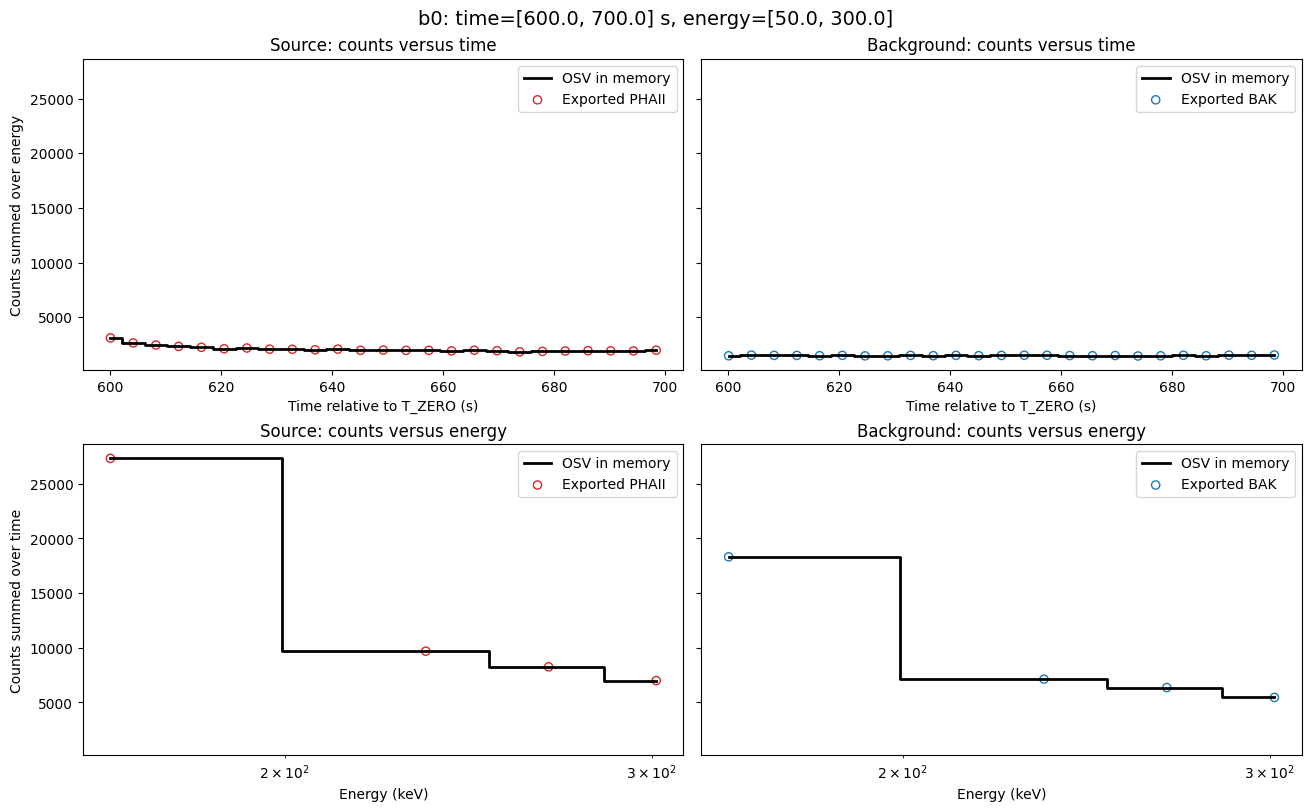

Source file: test_files\osv_phaii\glg_osv-cspec_T800-900_E50-300keV_221009554_b0.PHA
Background file: test_files\osv_phaii\glg_osv-cspec_T800-900_E50-300keV_221009554_b0.BAK
Compared shape: (25, 4)
Maximum source |PHAII − OSV|: 1.7621459846850485e-12
Maximum background |BAK − OSV|: 1.8189894035458565e-12


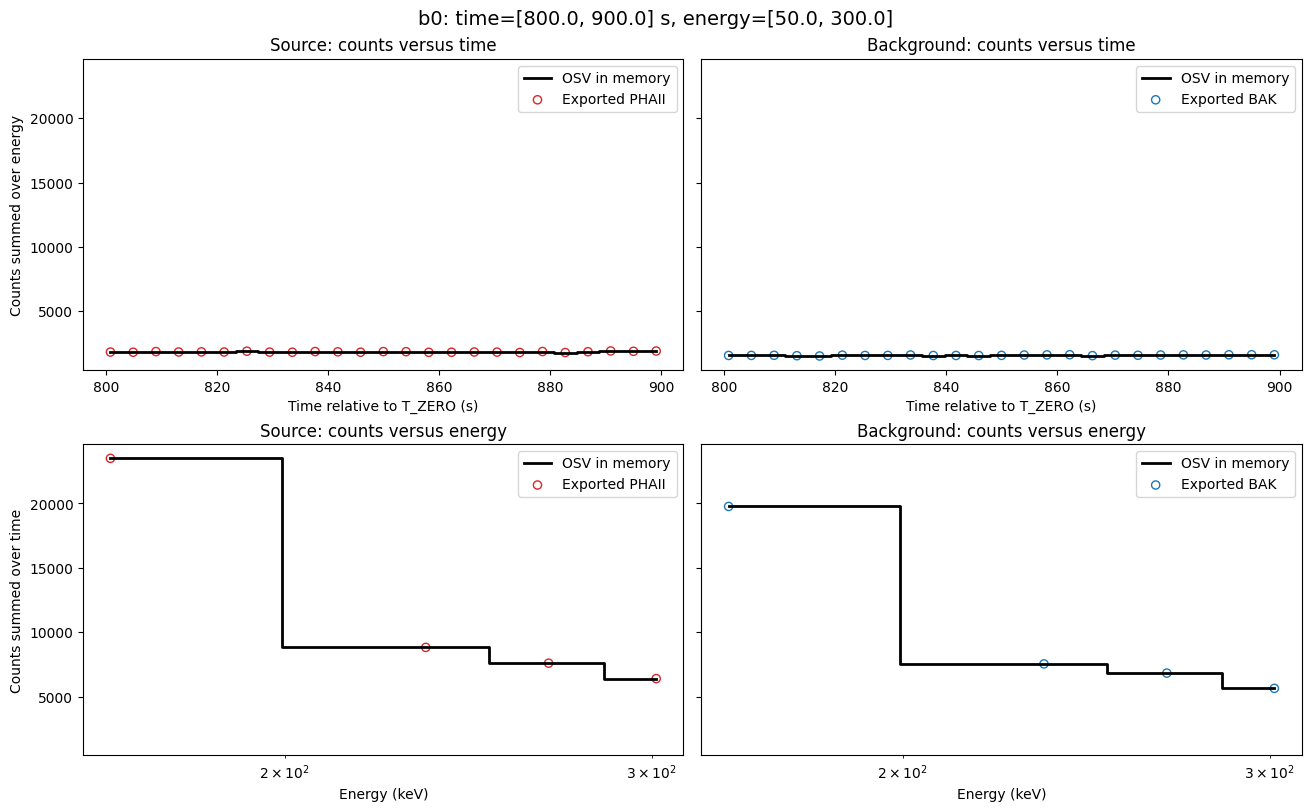

Source file: test_files\osv_phaii\glg_osv-cspec_T1000-1100_fullE_221009554_b0.PHA
Background file: test_files\osv_phaii\glg_osv-cspec_T1000-1100_fullE_221009554_b0.BAK
Compared shape: (25, 128)
Maximum source |PHAII − OSV|: 1.8189894035458565e-12
Maximum background |BAK − OSV|: 1.8189894035458565e-12


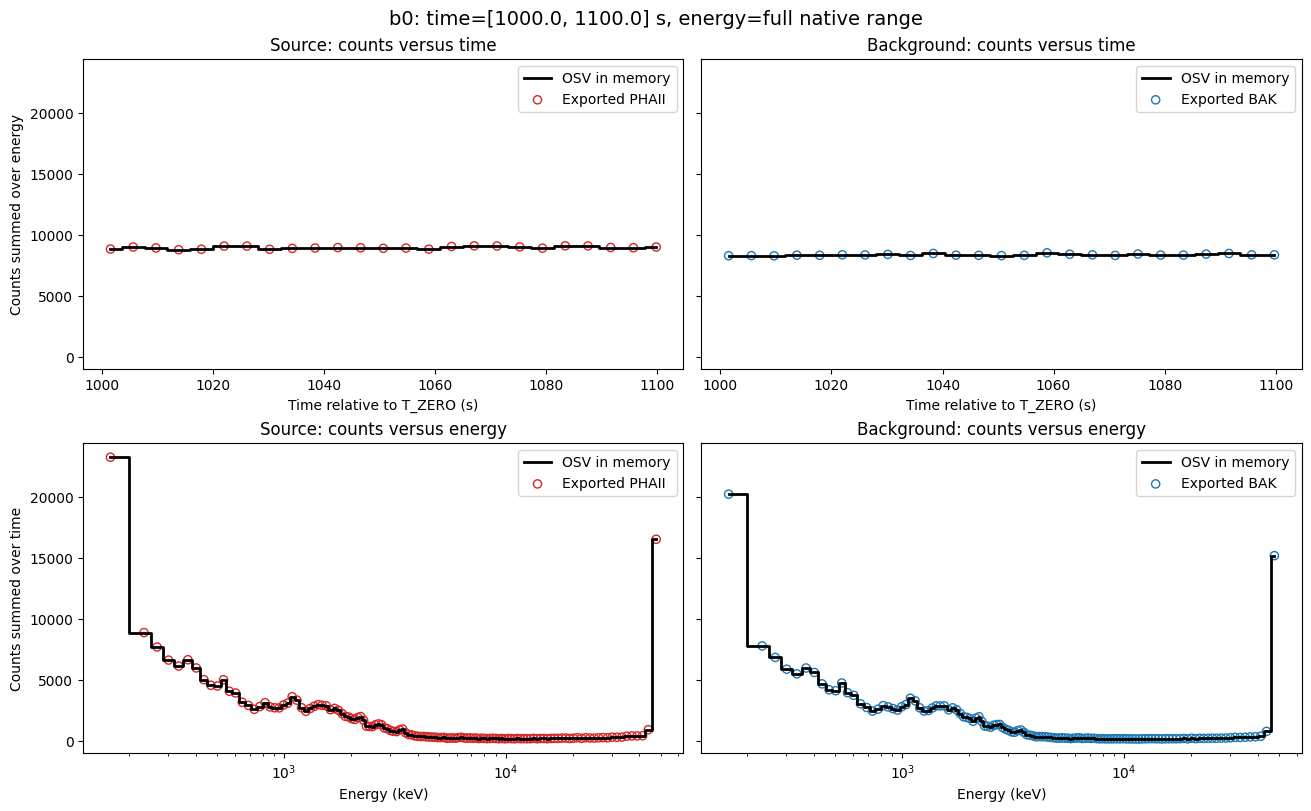

Source file: test_files\osv_phaii\glg_osv-cspec_T1100-1200_fullE_221009554_b0.PHA
Background file: test_files\osv_phaii\glg_osv-cspec_T1100-1200_fullE_221009554_b0.BAK
Compared shape: (24, 128)
Maximum source |PHAII − OSV|: 1.8189894035458565e-12
Maximum background |BAK − OSV|: 1.8189894035458565e-12


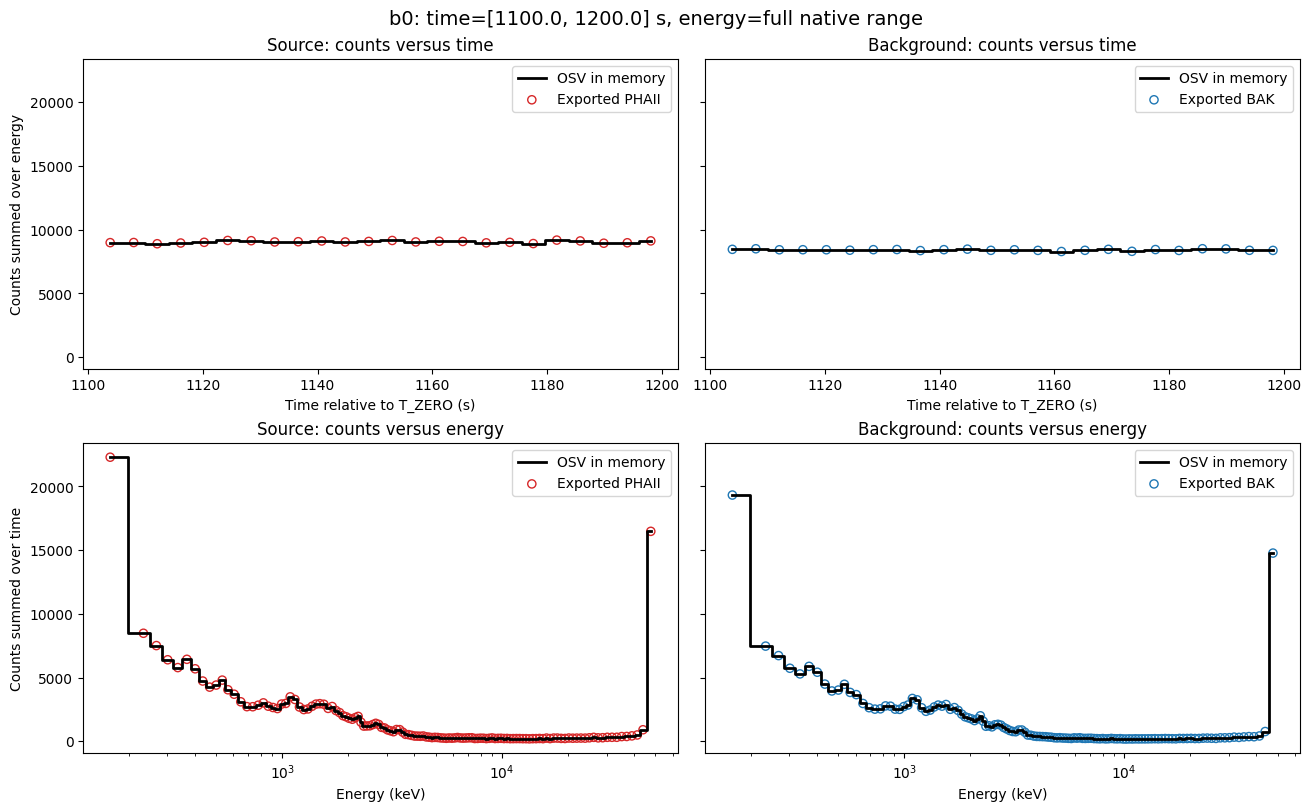

Source file: test_files\osv_phaii\glg_osv-cspec_T1200-1300_fullE_221009554_b0.PHA
Background file: test_files\osv_phaii\glg_osv-cspec_T1200-1300_fullE_221009554_b0.BAK
Compared shape: (24, 128)
Maximum source |PHAII − OSV|: 1.8189894035458565e-12
Maximum background |BAK − OSV|: 1.8189894035458565e-12


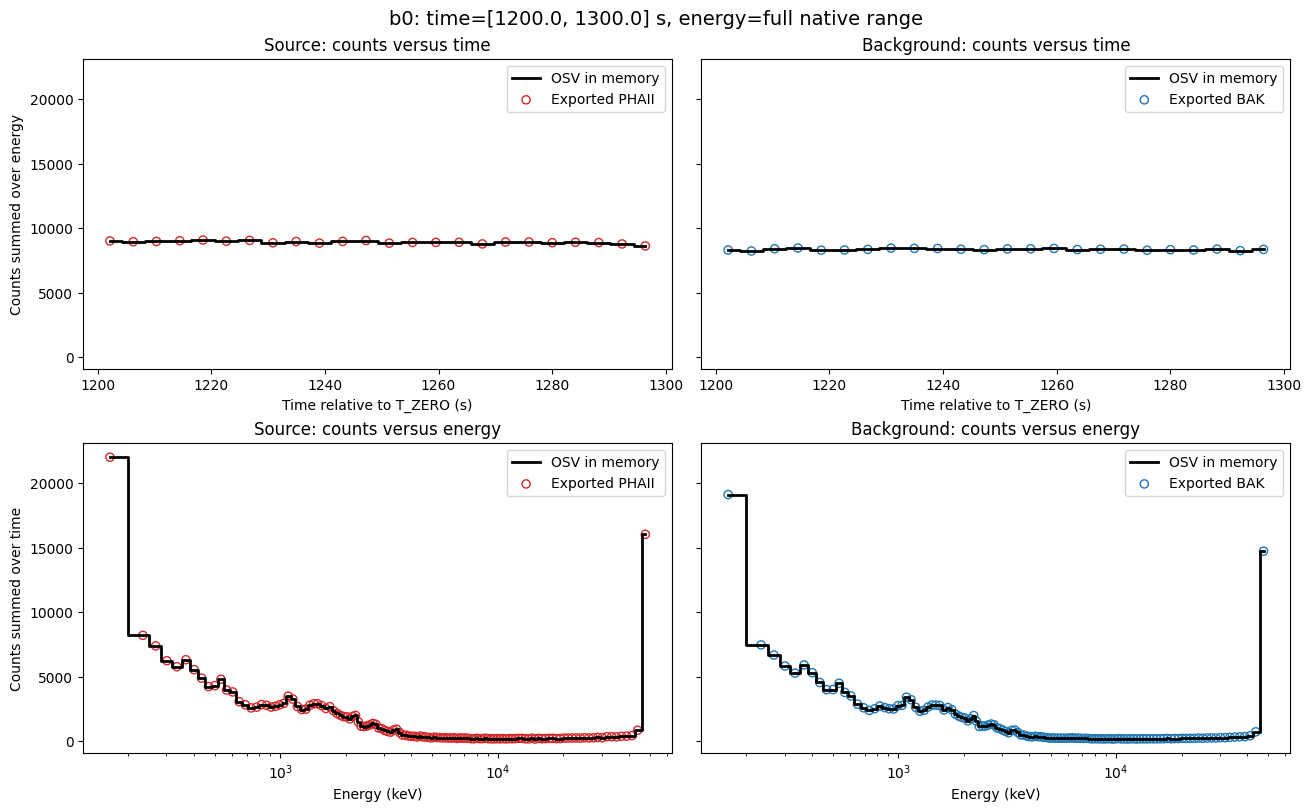

Source file: test_files\osv_phaii\glg_osv-cspec_T1300-1400_fullE_221009554_b0.PHA
Background file: test_files\osv_phaii\glg_osv-cspec_T1300-1400_fullE_221009554_b0.BAK
Compared shape: (25, 128)
Maximum source |PHAII − OSV|: 1.8189894035458565e-12
Maximum background |BAK − OSV|: 1.8189894035458565e-12


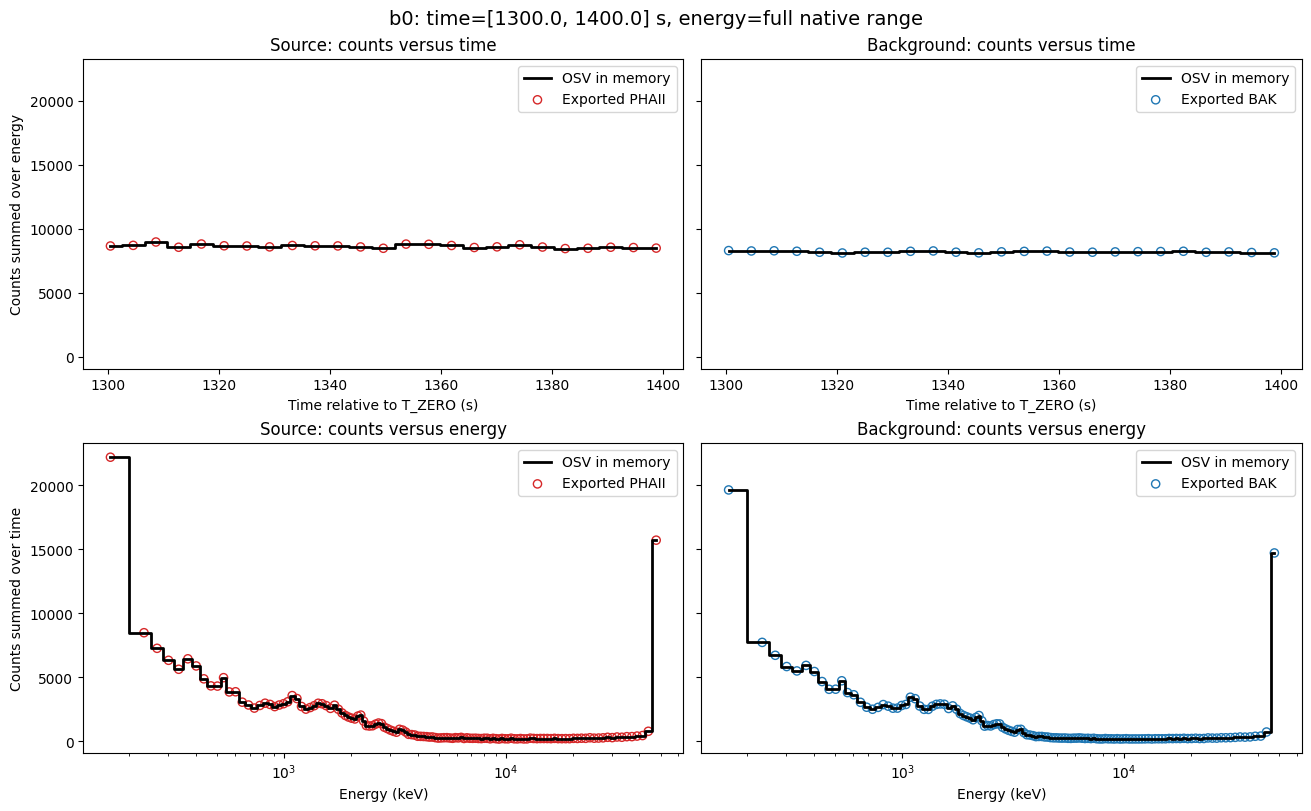

Source file: test_files\osv_phaii\glg_osv-cspec_T1400-1500_fullE_221009554_b0.PHA
Background file: test_files\osv_phaii\glg_osv-cspec_T1400-1500_fullE_221009554_b0.BAK
Compared shape: (24, 128)
Maximum source |PHAII − OSV|: 1.8189894035458565e-12
Maximum background |BAK − OSV|: 1.8189894035458565e-12


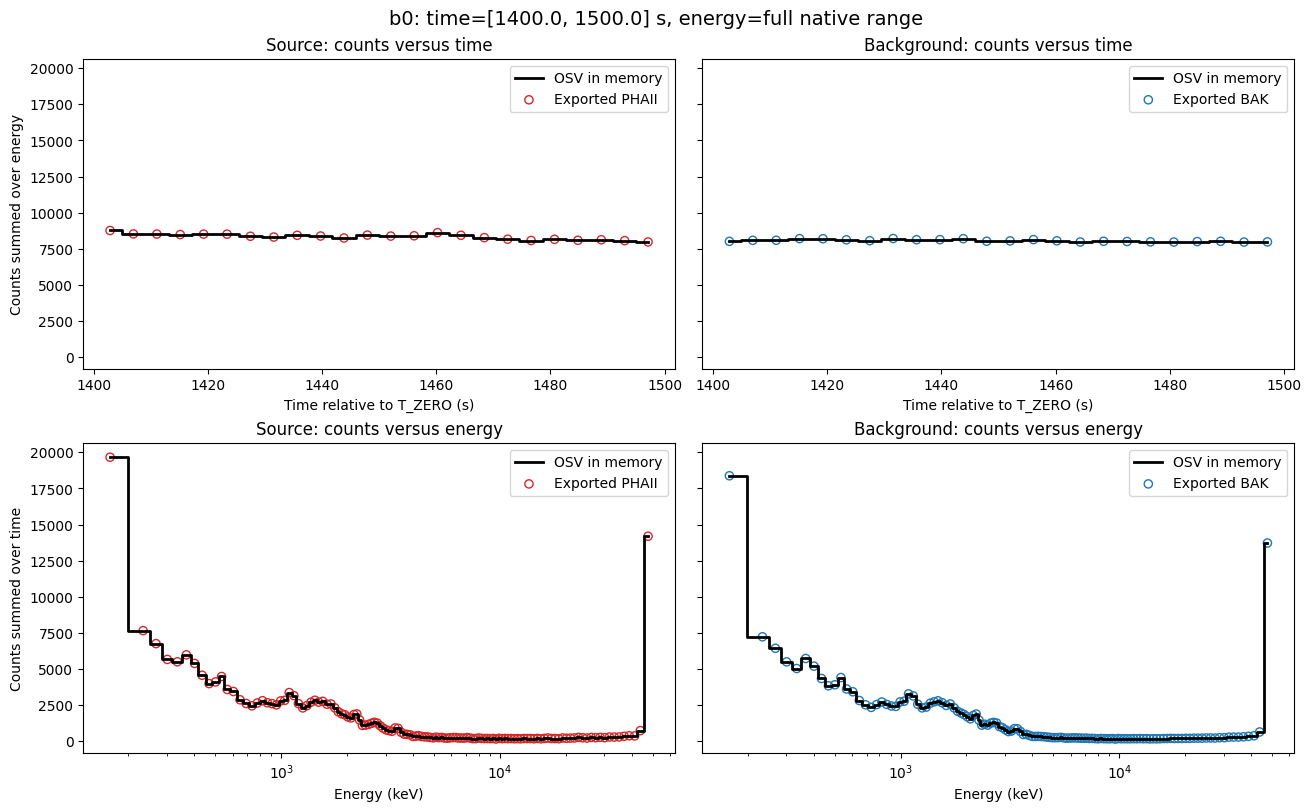

Source file: test_files\osv_phaii\glg_osv-cspec_T1500-1600_fullE_221009554_b0.PHA
Background file: test_files\osv_phaii\glg_osv-cspec_T1500-1600_fullE_221009554_b0.BAK
Compared shape: (25, 128)
Maximum source |PHAII − OSV|: 1.8189894035458565e-12
Maximum background |BAK − OSV|: 1.8189894035458565e-12


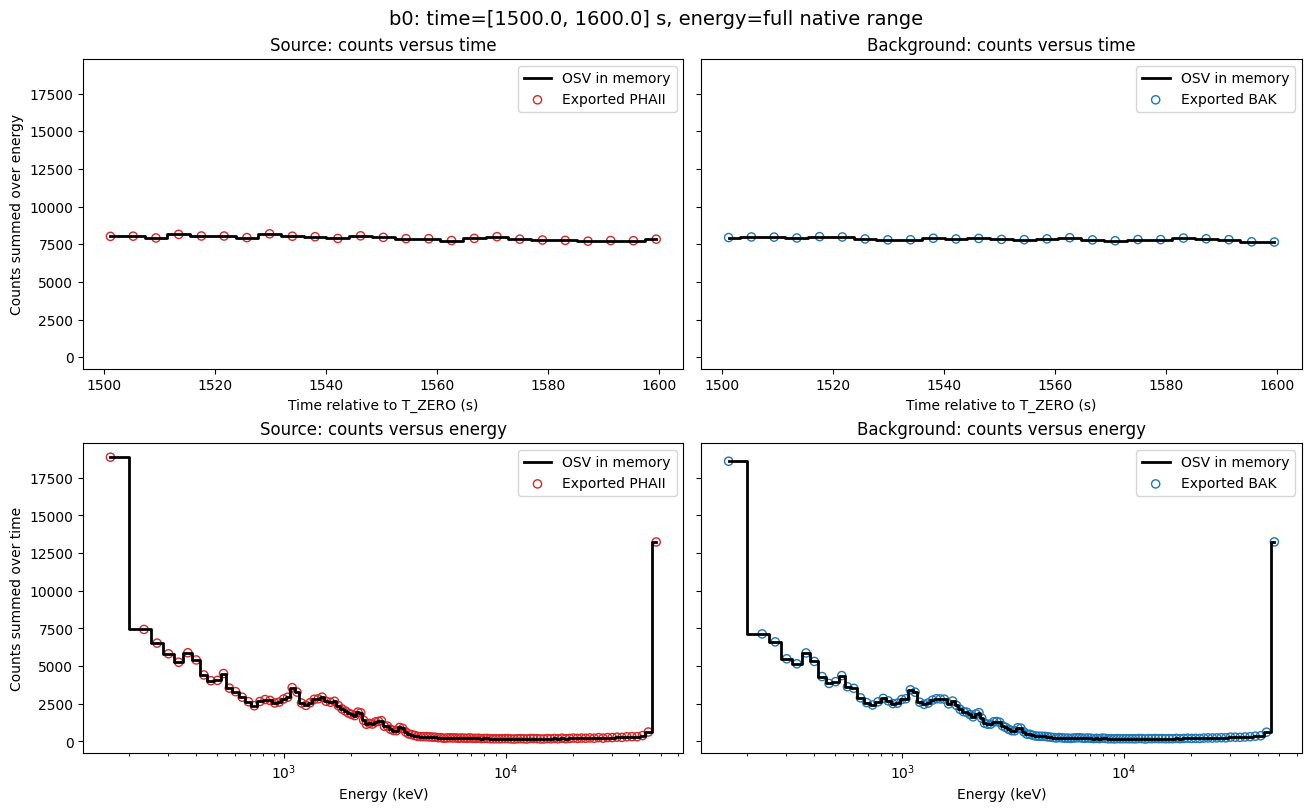

Source file: test_files\osv_phaii\glg_osv-cspec_T1600-1700_fullE_221009554_b0.PHA
Background file: test_files\osv_phaii\glg_osv-cspec_T1600-1700_fullE_221009554_b0.BAK
Compared shape: (24, 128)
Maximum source |PHAII − OSV|: 1.8189894035458565e-12
Maximum background |BAK − OSV|: 1.8189894035458565e-12


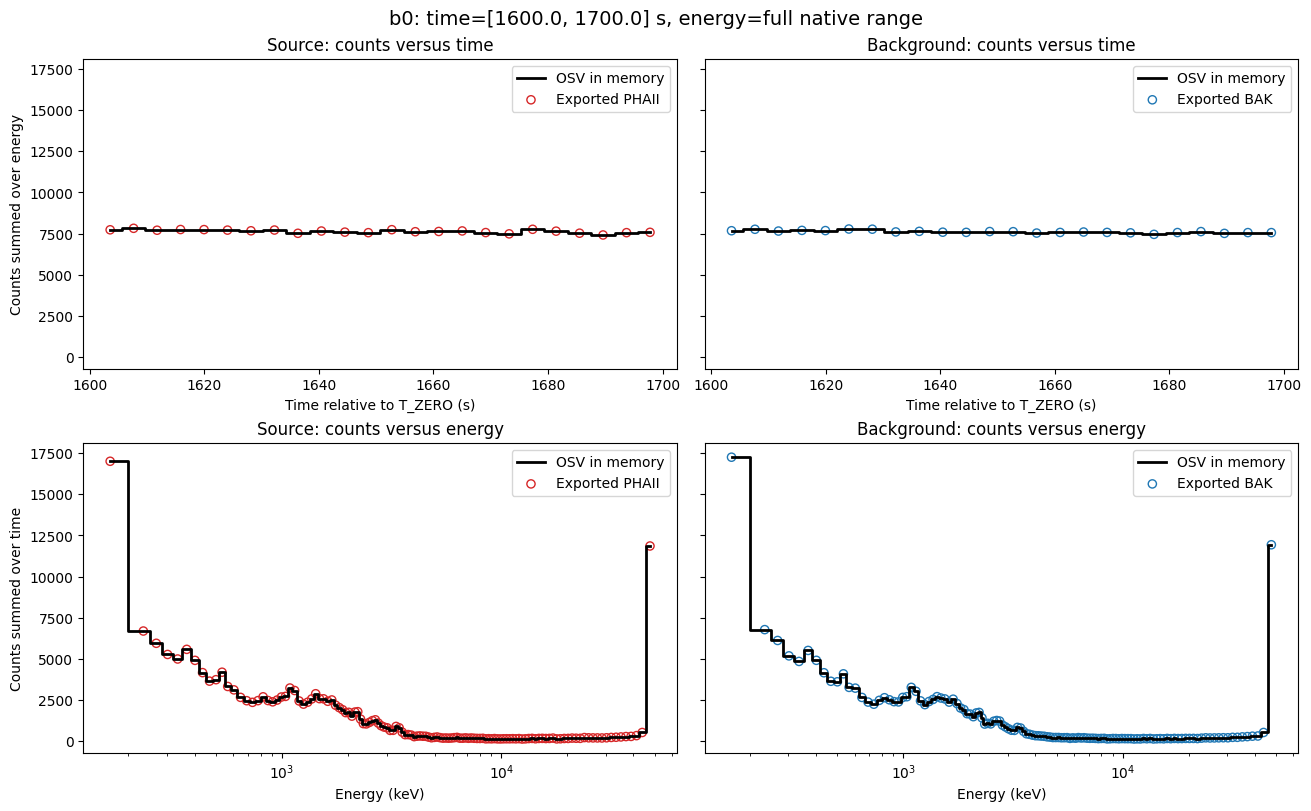

Source file: test_files\osv_phaii\glg_osv-cspec_T280-300_E50-300keV_221009554_b1.PHA
Background file: test_files\osv_phaii\glg_osv-cspec_T280-300_E50-300keV_221009554_b1.BAK
Compared shape: (5, 6)
Maximum source |PHAII − OSV|: 1.8189894035458565e-12
Maximum background |BAK − OSV|: 1.7053025658242404e-12


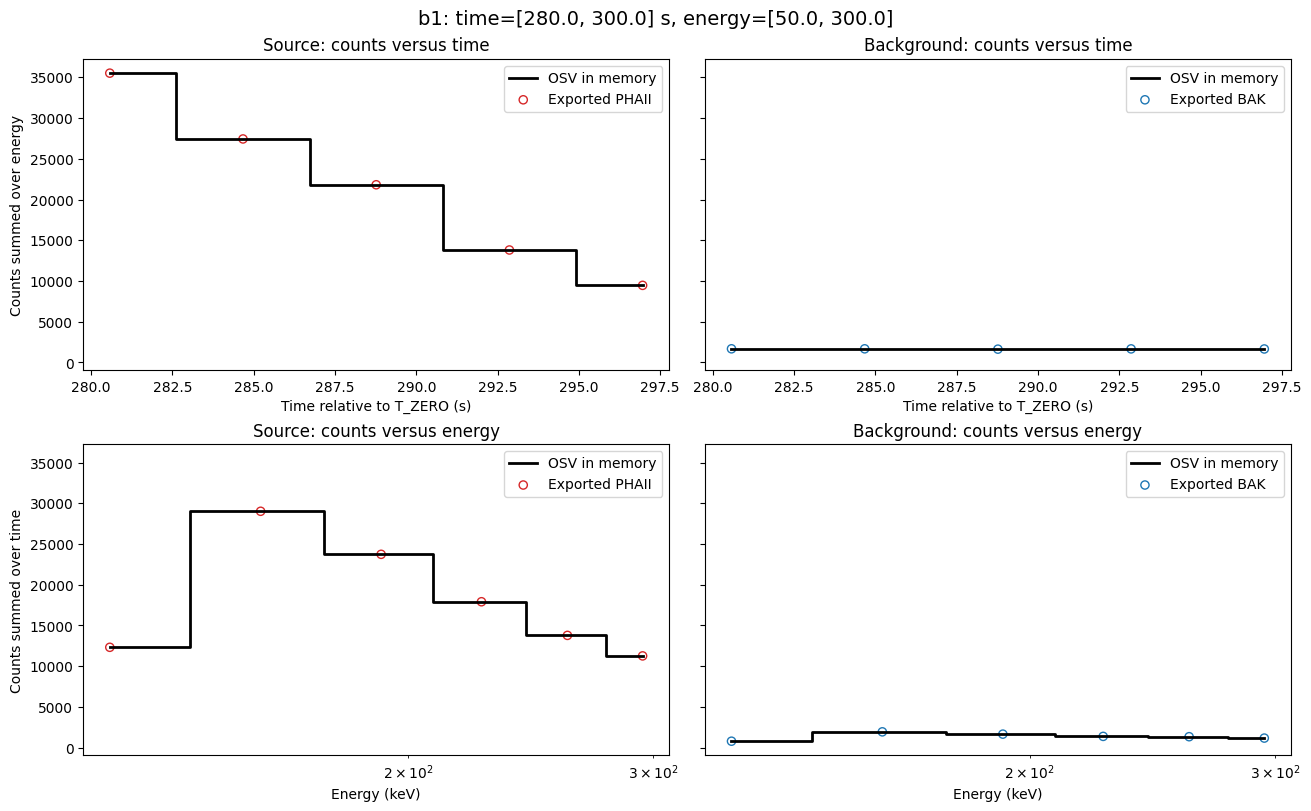

Source file: test_files\osv_phaii\glg_osv-cspec_T300-320_E50-300keV_221009554_b1.PHA
Background file: test_files\osv_phaii\glg_osv-cspec_T300-320_E50-300keV_221009554_b1.BAK
Compared shape: (5, 6)
Maximum source |PHAII − OSV|: 1.6484591469634324e-12
Maximum background |BAK − OSV|: 1.8189894035458565e-12


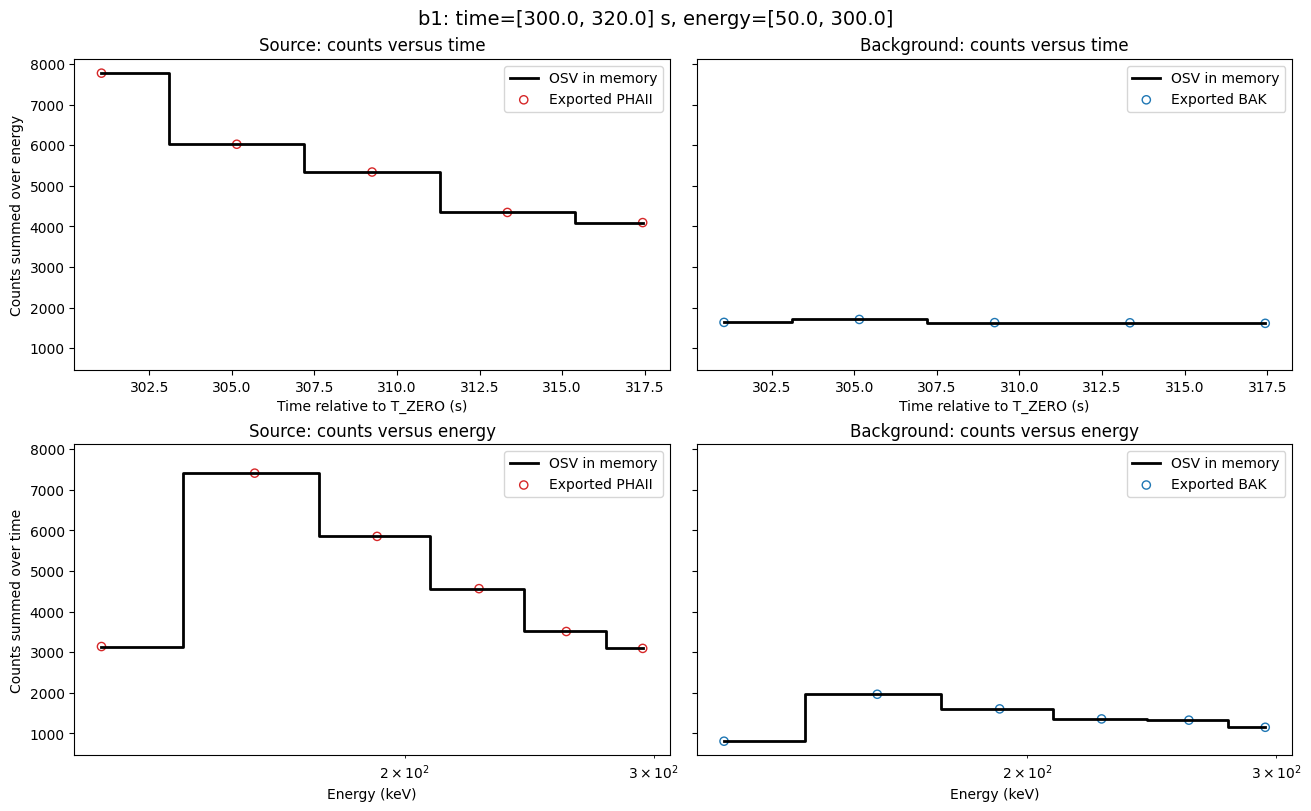

Source file: test_files\osv_phaii\glg_osv-cspec_T400-500_E50-300keV_221009554_b1.PHA
Background file: test_files\osv_phaii\glg_osv-cspec_T400-500_E50-300keV_221009554_b1.BAK
Compared shape: (24, 6)
Maximum source |PHAII − OSV|: 1.8189894035458565e-12
Maximum background |BAK − OSV|: 1.8189894035458565e-12


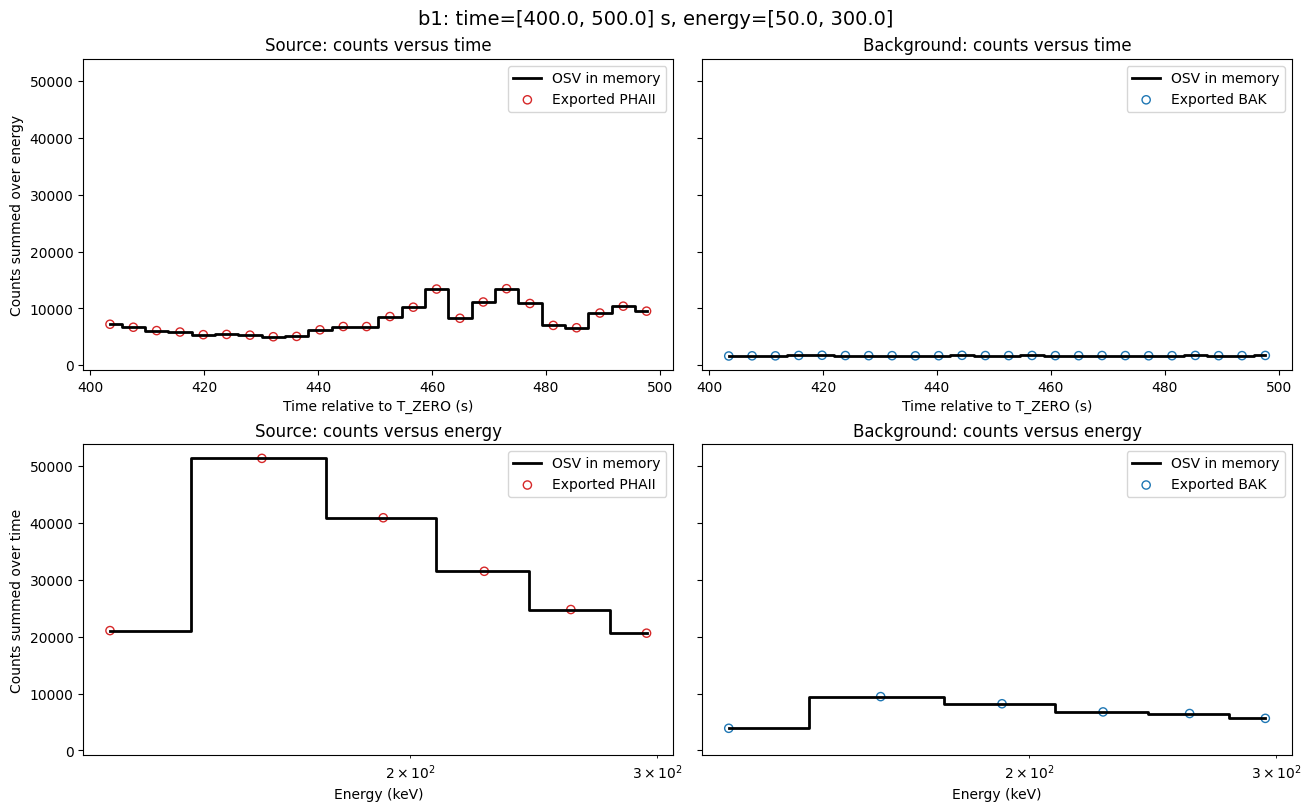

Source file: test_files\osv_phaii\glg_osv-cspec_T600-700_E50-300keV_221009554_b1.PHA
Background file: test_files\osv_phaii\glg_osv-cspec_T600-700_E50-300keV_221009554_b1.BAK
Compared shape: (25, 6)
Maximum source |PHAII − OSV|: 1.8189894035458565e-12
Maximum background |BAK − OSV|: 1.8189894035458565e-12


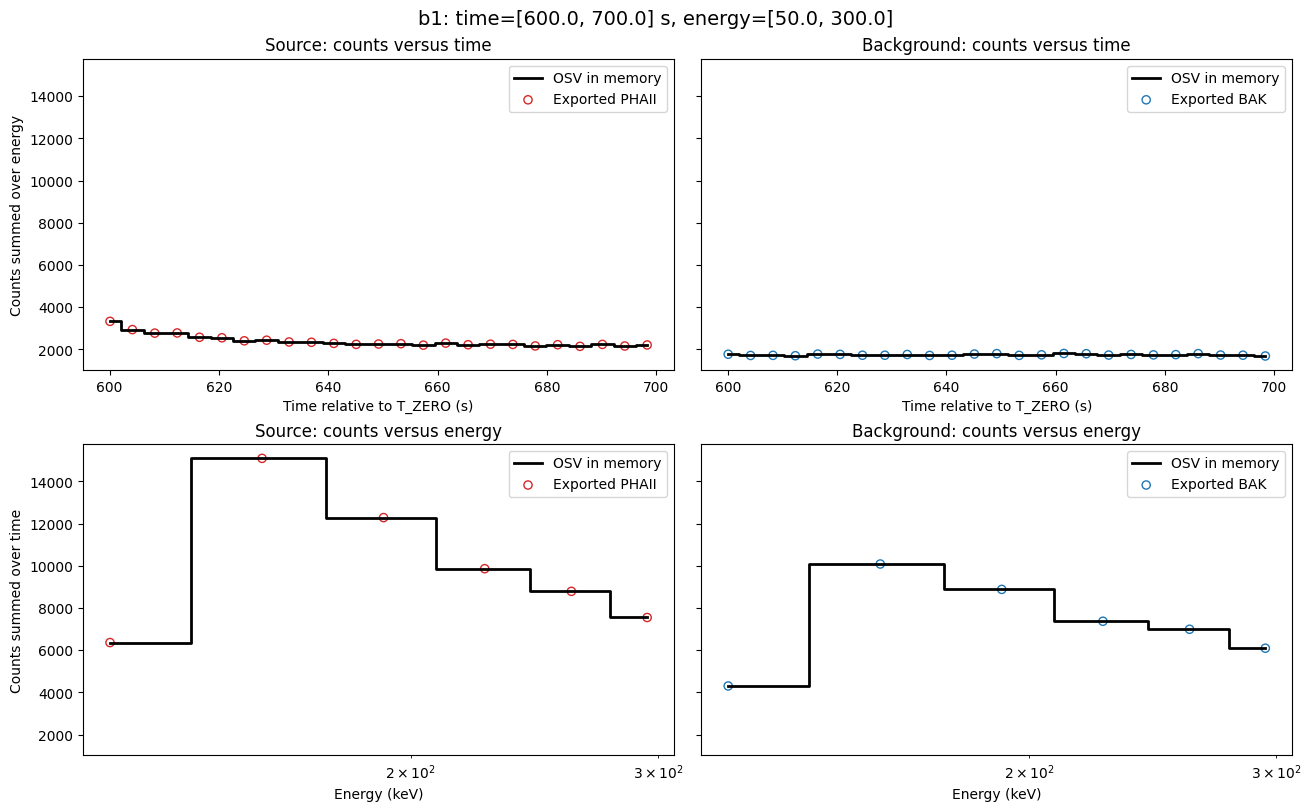

Source file: test_files\osv_phaii\glg_osv-cspec_T800-900_E50-300keV_221009554_b1.PHA
Background file: test_files\osv_phaii\glg_osv-cspec_T800-900_E50-300keV_221009554_b1.BAK
Compared shape: (25, 6)
Maximum source |PHAII − OSV|: 1.7621459846850485e-12
Maximum background |BAK − OSV|: 1.8189894035458565e-12


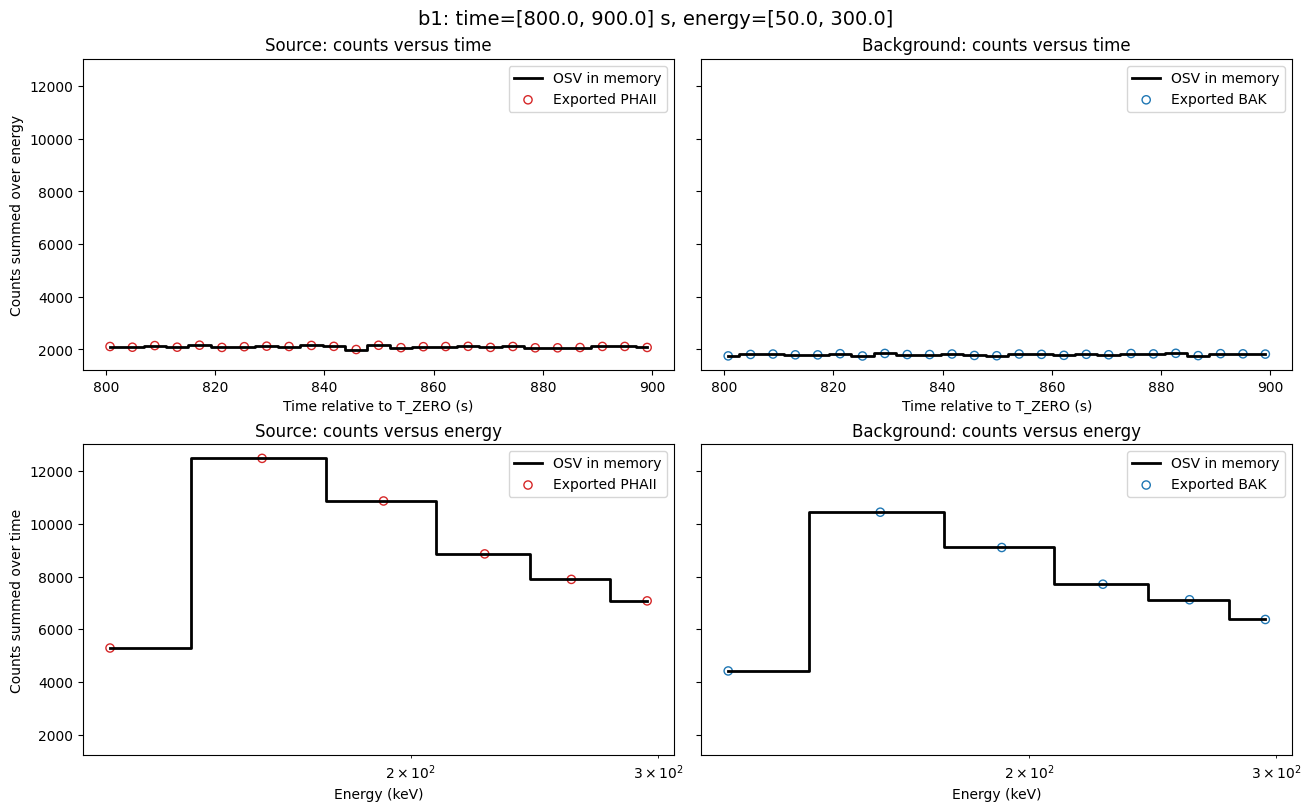

Source file: test_files\osv_phaii\glg_osv-cspec_T1000-1100_fullE_221009554_b1.PHA
Background file: test_files\osv_phaii\glg_osv-cspec_T1000-1100_fullE_221009554_b1.BAK
Compared shape: (25, 128)
Maximum source |PHAII − OSV|: 1.8189894035458565e-12
Maximum background |BAK − OSV|: 1.8189894035458565e-12


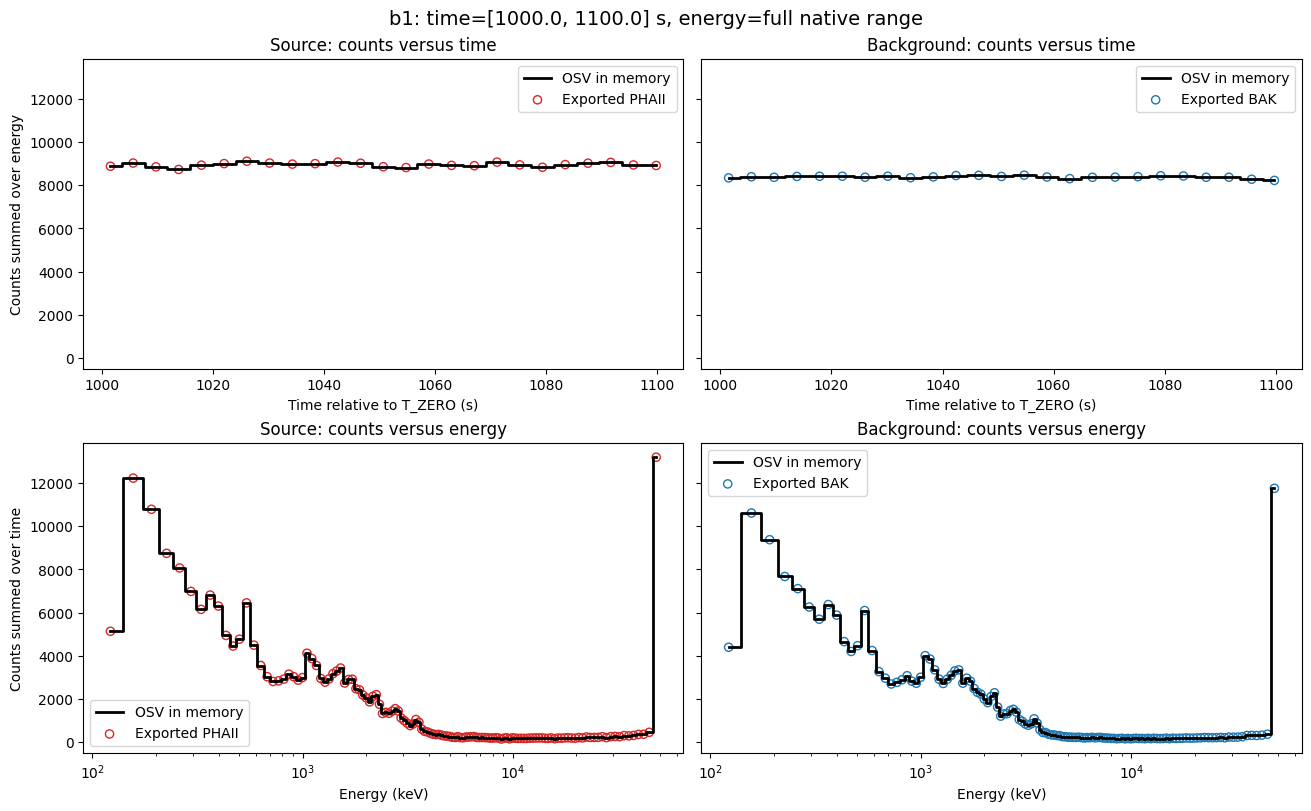

Source file: test_files\osv_phaii\glg_osv-cspec_T1100-1200_fullE_221009554_b1.PHA
Background file: test_files\osv_phaii\glg_osv-cspec_T1100-1200_fullE_221009554_b1.BAK
Compared shape: (24, 128)
Maximum source |PHAII − OSV|: 1.8189894035458565e-12
Maximum background |BAK − OSV|: 1.8189894035458565e-12


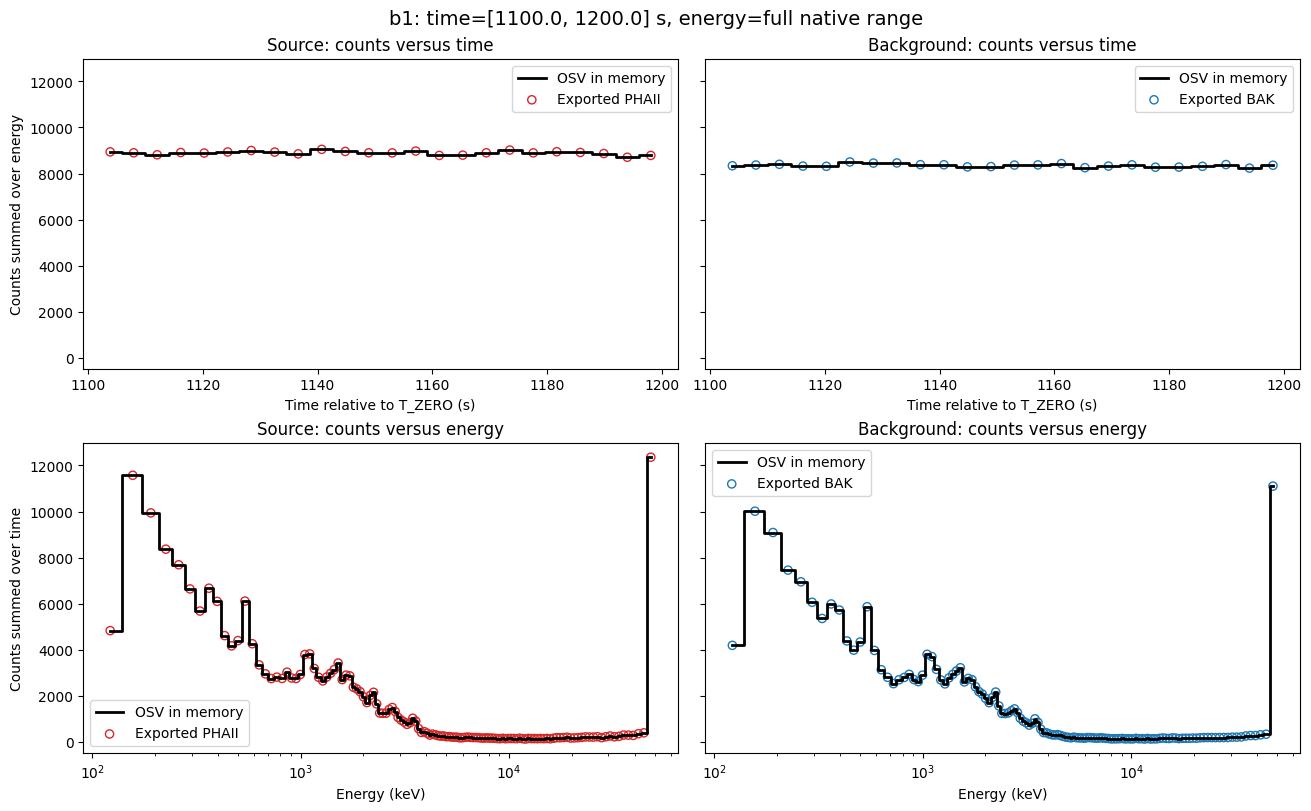

Source file: test_files\osv_phaii\glg_osv-cspec_T1200-1300_fullE_221009554_b1.PHA
Background file: test_files\osv_phaii\glg_osv-cspec_T1200-1300_fullE_221009554_b1.BAK
Compared shape: (24, 128)
Maximum source |PHAII − OSV|: 1.8189894035458565e-12
Maximum background |BAK − OSV|: 1.8189894035458565e-12


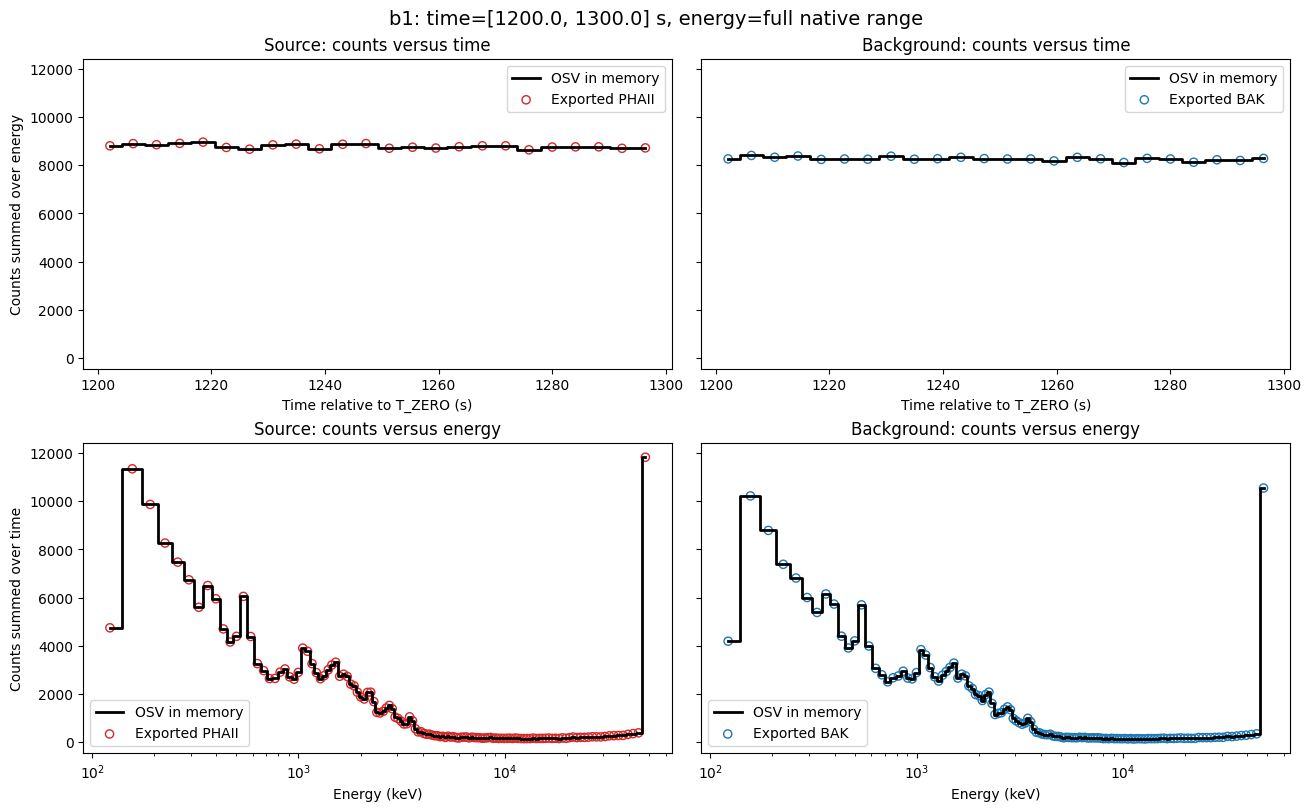

Source file: test_files\osv_phaii\glg_osv-cspec_T1300-1400_fullE_221009554_b1.PHA
Background file: test_files\osv_phaii\glg_osv-cspec_T1300-1400_fullE_221009554_b1.BAK
Compared shape: (25, 128)
Maximum source |PHAII − OSV|: 1.8189894035458565e-12
Maximum background |BAK − OSV|: 1.8189894035458565e-12


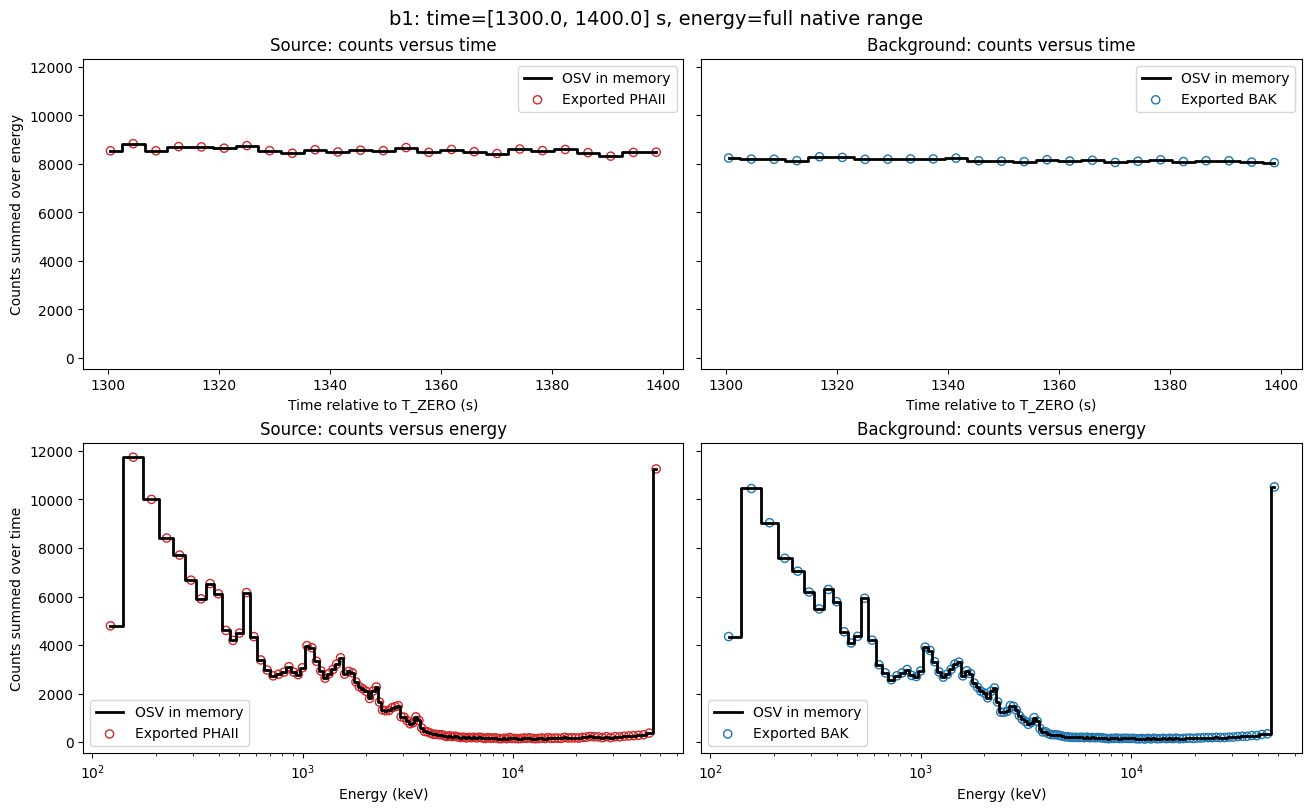

Source file: test_files\osv_phaii\glg_osv-cspec_T1400-1500_fullE_221009554_b1.PHA
Background file: test_files\osv_phaii\glg_osv-cspec_T1400-1500_fullE_221009554_b1.BAK
Compared shape: (24, 128)
Maximum source |PHAII − OSV|: 1.8189894035458565e-12
Maximum background |BAK − OSV|: 1.8189894035458565e-12


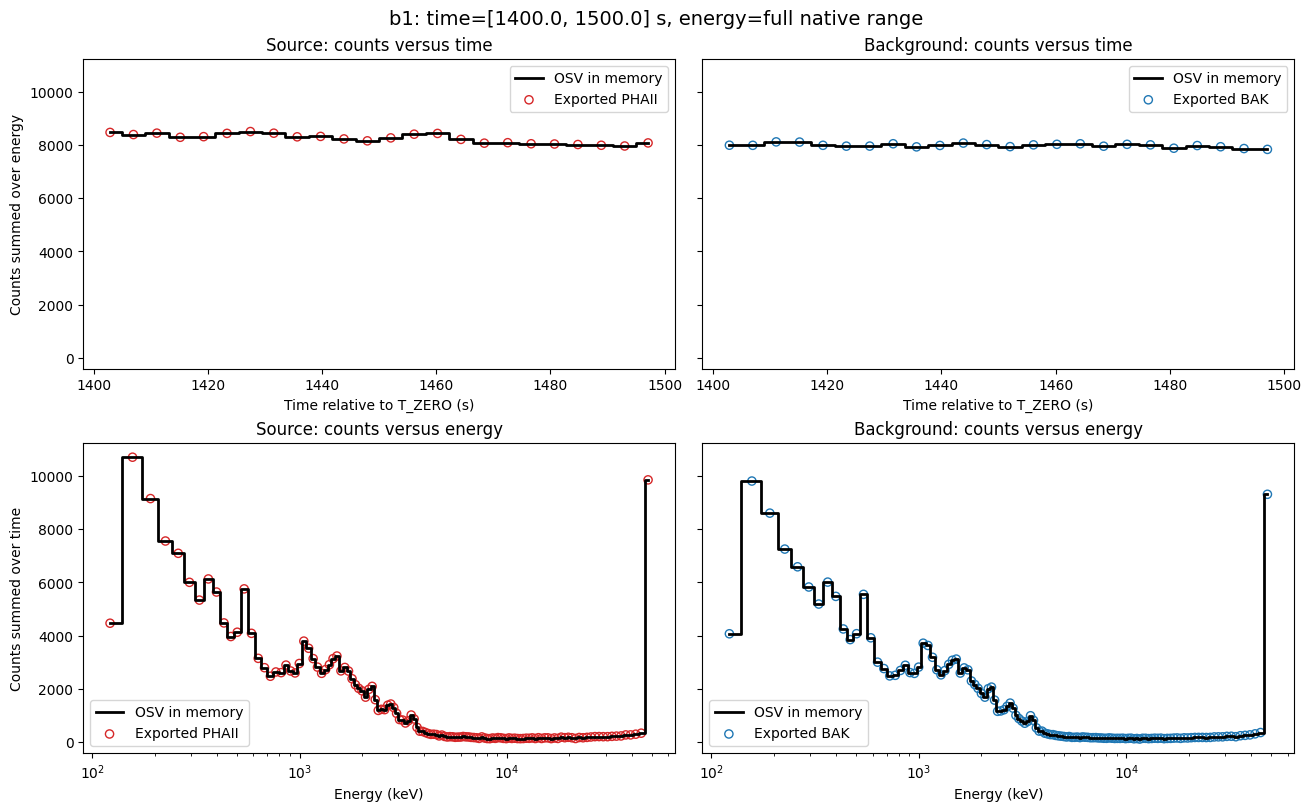

Source file: test_files\osv_phaii\glg_osv-cspec_T1500-1600_fullE_221009554_b1.PHA
Background file: test_files\osv_phaii\glg_osv-cspec_T1500-1600_fullE_221009554_b1.BAK
Compared shape: (25, 128)
Maximum source |PHAII − OSV|: 1.8189894035458565e-12
Maximum background |BAK − OSV|: 1.8189894035458565e-12


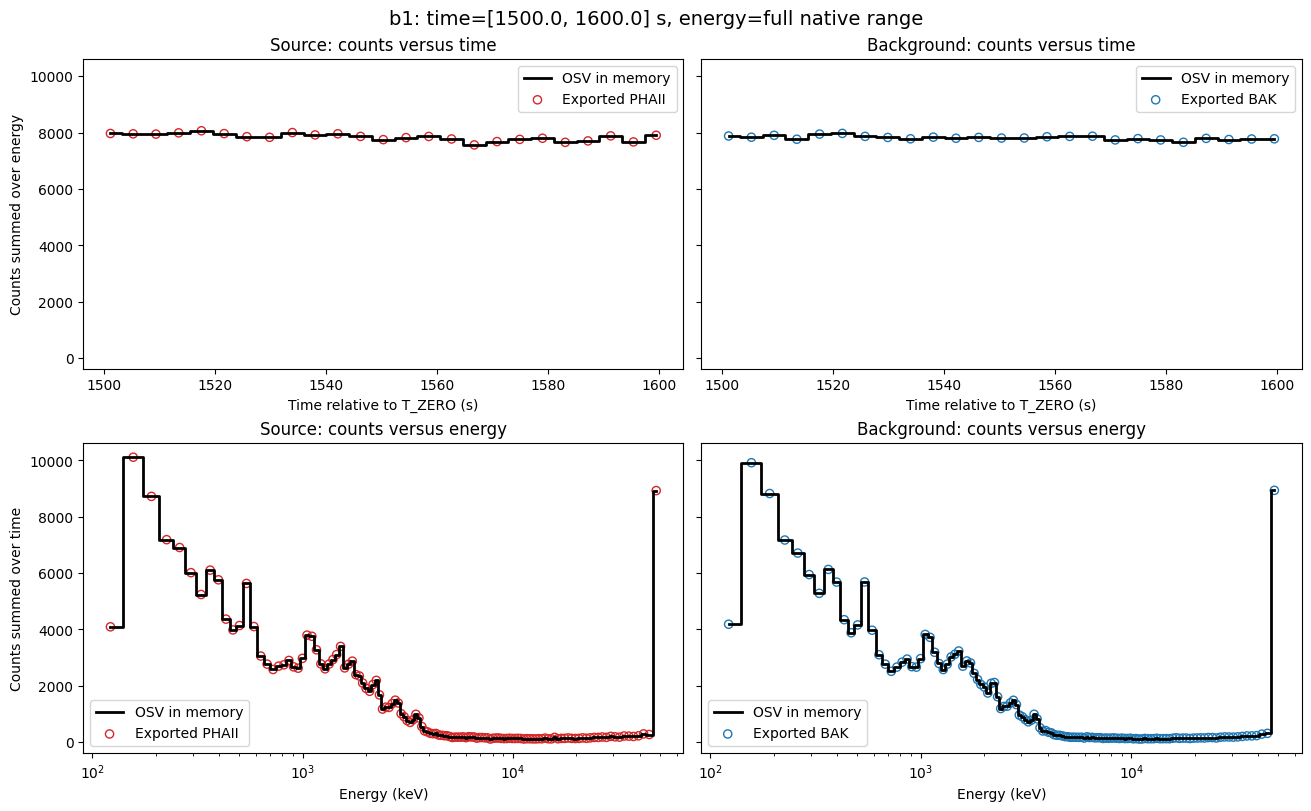

Source file: test_files\osv_phaii\glg_osv-cspec_T1600-1700_fullE_221009554_b1.PHA
Background file: test_files\osv_phaii\glg_osv-cspec_T1600-1700_fullE_221009554_b1.BAK
Compared shape: (24, 128)
Maximum source |PHAII − OSV|: 1.8189894035458565e-12
Maximum background |BAK − OSV|: 1.8189894035458565e-12


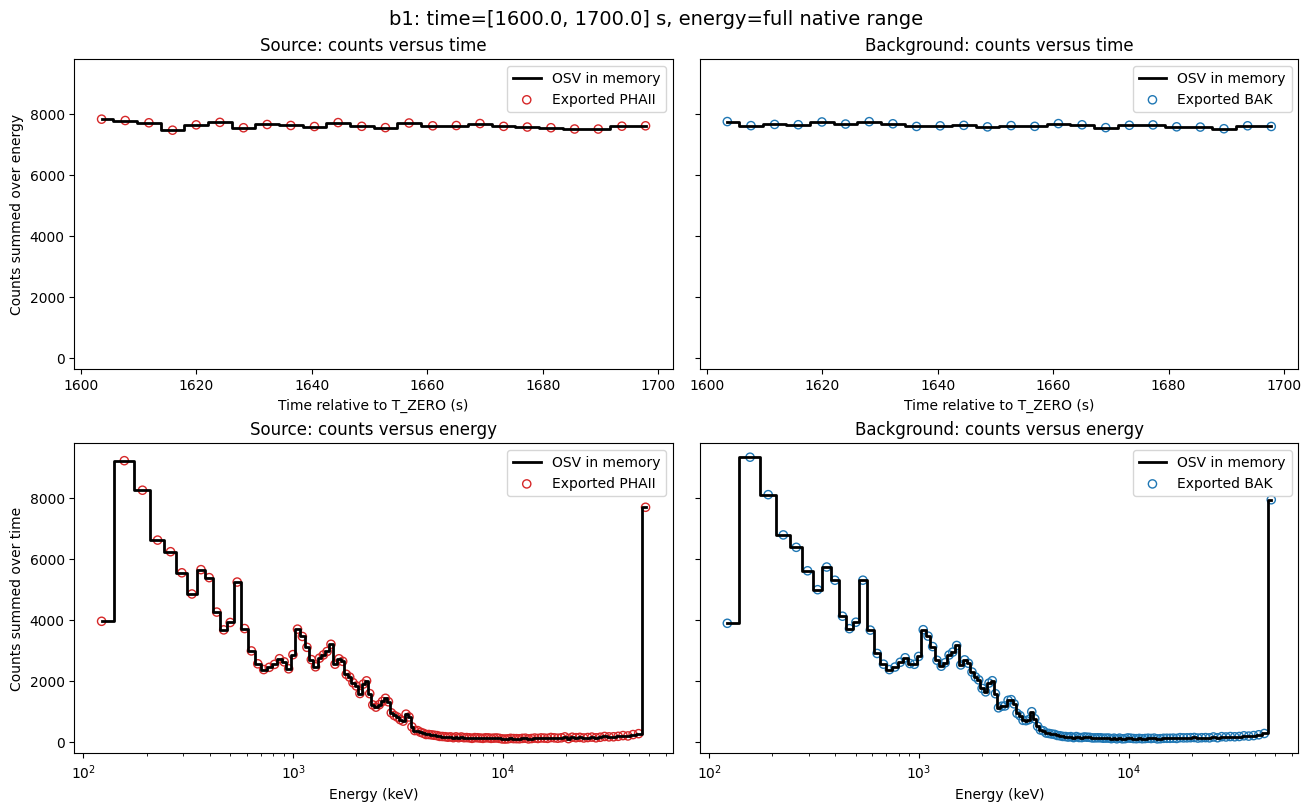

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

def read_phaii(path):
    """Read the arrays needed for comparison."""
    with fits.open(path, memmap=False) as hdul:
        spectrum = hdul["SPECTRUM"].data
        ebounds = hdul["EBOUNDS"].data

        return {
            "time_start": np.array(spectrum["TIME"], dtype=float),
            "time_stop": np.array(spectrum["ENDTIME"], dtype=float),
            "counts": np.array(spectrum["COUNTS"], dtype=float),
            "energy_min": np.array(ebounds["E_MIN"], dtype=float),
            "energy_max": np.array(ebounds["E_MAX"], dtype=float),
        }

def nearest_indices(reference, requested, label, atol):
    """Match exported native bins back to OSV's in-memory bins."""
    reference = np.asarray(reference)
    requested = np.asarray(requested)

    indices = np.array([
        np.argmin(np.abs(reference - value))
        for value in requested
    ])

    if not np.allclose(reference[indices], requested, rtol=1e-5, atol=atol):
        raise ValueError(f"Could not reliably match the exported {label} bins.")

    return indices

def compare_export(record):
    detector = record["detector"]
    osv_data = OSV_RESULT.data[detector]

    source_file     = read_phaii(record["source"])
    background_file = read_phaii(record["background"])

    # Confirm that source and background use identical binning.
    assert np.allclose(source_file["time_start"], background_file["time_start"])
    assert np.allclose(source_file["energy_min"], background_file["energy_min"])

    # Original OSV time and energy bin centres.
    original_time_edges     = np.asarray(osv_data.data["src"][0])
    original_time_centres   = original_time_edges.mean(axis=1)

    original_energy_centres = 0.5 * (
        np.asarray(osv_data.eEdgeMin)
        + np.asarray(osv_data.eEdgeMax)
    )

    exported_time_centres = 0.5 * (
        source_file["time_start"]
        + source_file["time_stop"]
    )

    exported_energy_centres = 0.5 * (
        source_file["energy_min"]
        + source_file["energy_max"]
    )

    # Match exported bins to their original OSV bins.
    time_indices = nearest_indices(
        original_time_centres,
        exported_time_centres,
        label="time",
        atol=1e-3,
    )

    energy_indices = nearest_indices(
        original_energy_centres,
        exported_energy_centres,
        label="energy",
        atol=1e-2,
    )

    # Extract exactly the same bins from the in-memory OSV result.
    original_source = np.asarray(
        osv_data.data["src"][1], dtype=float
    )[np.ix_(time_indices, energy_indices)]

    original_background = np.asarray(
        osv_data.background["all"], dtype=float
    )[np.ix_(time_indices, energy_indices)]

    written_source      = source_file["counts"]
    written_background  = background_file["counts"]

    assert original_source.shape        == written_source.shape
    assert original_background.shape    == written_background.shape

    relative_time = exported_time_centres - float(T_ZERO)

    fig, axes = plt.subplots(
        2, 2,
        figsize=(13, 8),
        constrained_layout=True,
        sharey=True
    )

    # Source light curve
    axes[0, 0].step(
        relative_time,
        original_source.sum(axis=1),
        where="mid",
        color="black",
        linewidth=2,
        label="OSV in memory",
    )
    axes[0, 0].scatter(
        relative_time,
        written_source.sum(axis=1),
        facecolors="none",
        edgecolors="tab:red",
        s=35,
        label="Exported PHAII",
    )
    axes[0, 0].set_title("Source: counts versus time")
    axes[0, 0].set_xlabel("Time relative to T_ZERO (s)")
    axes[0, 0].set_ylabel("Counts summed over energy")
    axes[0, 0].legend()

    # Background light curve
    axes[0, 1].step(
        relative_time,
        original_background.sum(axis=1),
        where="mid",
        color="black",
        linewidth=2,
        label="OSV in memory",
    )
    axes[0, 1].scatter(
        relative_time,
        written_background.sum(axis=1),
        facecolors="none",
        edgecolors="tab:blue",
        s=35,
        label="Exported BAK",
    )
    axes[0, 1].set_title("Background: counts versus time")
    axes[0, 1].set_xlabel("Time relative to T_ZERO (s)")
    axes[0, 1].legend()

    # Source spectrum
    axes[1, 0].step(
        exported_energy_centres,
        original_source.sum(axis=0),
        where="mid",
        color="black",
        linewidth=2,
        label="OSV in memory",
    )
    axes[1, 0].scatter(
        exported_energy_centres,
        written_source.sum(axis=0),
        facecolors="none",
        edgecolors="tab:red",
        s=35,
        label="Exported PHAII",
    )
    axes[1, 0].set_title("Source: counts versus energy")
    axes[1, 0].set_xlabel("Energy (keV)")
    axes[1, 0].set_ylabel("Counts summed over time")
    axes[1, 0].set_xscale("log")
    axes[1, 0].legend()

    # Background spectrum
    axes[1, 1].step(
        exported_energy_centres,
        original_background.sum(axis=0),
        where="mid",
        color="black",
        linewidth=2,
        label="OSV in memory",
    )
    axes[1, 1].scatter(
        exported_energy_centres,
        written_background.sum(axis=0),
        facecolors="none",
        edgecolors="tab:blue",
        s=35,
        label="Exported BAK",
    )
    axes[1, 1].set_title("Background: counts versus energy")
    axes[1, 1].set_xlabel("Energy (keV)")
    axes[1, 1].set_xscale("log")
    axes[1, 1].legend()

    fig.suptitle(
        f"{detector}: time={record['requested_time_s']} s, "
        f"energy={record['requested_energy_keV']}",
        fontsize=14,
    )

    source_difference = written_source - original_source
    background_difference = written_background - original_background

    print("Source file:", record["source"])
    print("Background file:", record["background"])
    print("Compared shape:", written_source.shape)
    print(
        "Maximum source difference |PHAII - OSV|:",
        np.max(np.abs(source_difference)),
    )
    print(
        "Maximum background |BAK - OSV|:",
        np.max(np.abs(background_difference)),
    )

    plt.show()


# Start with one pair to keep the output manageable.
EXPORT_INDEX = 0
compare_export(EXPORTS[EXPORT_INDEX])

# To inspect every exported pair, uncomment:
for record in EXPORTS:
     compare_export(record)